# Non-Linearity-Aware Gain Calibration Relative to Node7-Bogota

This notebook estimates per-node calibration models against `Node7-Bogota` using robust row filtering and level-dependent corrections.
The objective is to reduce node mismatch in PSD (dB) while handling gain-state changes and compression-like non-linear behavior.


## 1. Analytical Problem Formulation

For each non-reference node $i$, synchronized row $r$, and frequency bin $f$ on the reference axis, define:

- $P_{i,r}(f)$: node PSD in dB.
- $P_{\mathrm{ref},r}(f)$: reference PSD (`Node7-Bogota`) in dB.

The residual mismatch is

$$
\Delta_{i,r}(f) = P_{\mathrm{ref},r}(f) - P_{i,r}(f).
$$

The calibration seeks a robust correction model so the calibrated spectrum
$P^{\mathrm{cal}}_{i,r}(f)$ approaches $P_{\mathrm{ref},r}(f)$ across rows and frequency, even when row operating points vary.


## 2. Robust ROI Metrics and Clean-Row Mask

Inside the ROI $[97, 99]$ MHz, each row is summarized with robust metrics:

- $L_{i,r} = \operatorname{median}_f P_{i,r}(f)$ (row level).
- $F_{i,r} = \operatorname{percentile}_{10}(P_{i,r})$ (floor proxy).
- $S_{i,r} = \operatorname{percentile}_{90}(P_{i,r}) - \operatorname{percentile}_{10}(P_{i,r})$ (spread proxy).
- $R_{i,r} = \operatorname{median}_f |P_{\mathrm{ref},r}(f) - P_{i,r}(f)|$ (robust mismatch).

Rows are accepted as clean when they satisfy node-specific robust thresholds built from percentile and MAD rules:

- floor not excessively high,
- spread within a plausible range,
- mismatch not excessively large.

Only clean rows are used to fit transfer functions, reducing contamination from transient distortions.


## 3. Layered Non-Linearity Calibration Model

The notebook evaluates a progressive model:

1. **Layer A (frequency-only transfer):**
$$
H_i(f) = \operatorname{median}_{r \in \mathcal{C}_i}\, \Delta_{i,r}(f),
$$
where $\mathcal{C}_i$ is the clean-row set for node $i$.

2. **Layer B (row offset):**
$$
A_i(r) = \operatorname{median}_{f \in \mathrm{ROI}}\left(\Delta_{i,r}(f) - H_i(f)\right).
$$

3. **Layer C (level-dependent transfer):**
rows are grouped by level $L_{i,r}$ into quantile bins $k$, then
$$
H_{i,k}(f) = \operatorname{median}_{r \in k}\, \Delta_{i,r}(f).
$$
For evaluation rows, the model selects/interpolates $H_i(f, L_{i,r})$ from neighboring bins.

Calibrated variants are therefore:

- $P_i + H_i$,
- $P_i + H_i + A_i(r)$,
- $P_i + H_i(f, L_{i,r})$,
- $P_i + H_i(f, L_{i,r}) + A_i(r)$.


## 4. Frequency Alignment and Robust Estimation

Each row is interpolated onto the reference frequency axis before computing $\Delta_{i,r}(f)$.
Rows with insufficient valid bins are discarded, and nodes with no overlap with Node7 are skipped.

All transfer curves are smoothed with a NaN-aware moving average to suppress narrow random artifacts while preserving broad spectral trends.


## 5. Fit Quality Metrics

Performance is reported in the ROI using robust median absolute error (MAE):

$$
\mathrm{MAE}_{\mathrm{variant}} = \operatorname{median}_{r,\,f \in \mathrm{ROI}}\left|P_{\mathrm{ref},r}(f) - P^{\mathrm{cal}}_{i,r,\,\mathrm{variant}}(f)\right|.
$$

The notebook compares baseline, $H$, $H{+}A$, $H(L)$, and $H(L){+}A$ to quantify the benefit of each layer.
Positive MAE reduction indicates improved agreement with the reference node.


In [3]:
from __future__ import annotations

import ast
import glob
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd


# -----------------------
# Configuration
# -----------------------
DATA_GLOB = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"
REFERENCE_NODE = "Node7-Bogota"
PXX_COLUMN = "pxx"
ROI_MHZ = (97.0, 99.0)
SMOOTHING_BINS = 129
MIN_ROWS_FOR_FIT = 10
MIN_VALID_BINS_PER_ROW = 32
MIN_VALID_FRACTION_PER_ROW = 0.10

# ROI metric percentiles.
ROI_FLOOR_PERCENTILE = 10.0
ROI_SPREAD_LOW_PERCENTILE = 10.0
ROI_SPREAD_HIGH_PERCENTILE = 90.0

# Robust threshold parameters (data-driven from each node's row metrics).
THRESHOLD_LOW_PERCENTILE = 5.0
THRESHOLD_HIGH_PERCENTILE = 95.0
THRESHOLD_MAD_SCALE = 3.5

# Offset-layer configuration.
OFFSET_LAYER_ROI_MHZ = ROI_MHZ
USE_CLEAN_ROWS_FOR_OFFSET = True

# Level-dependent transfer layer (Layer C) configuration.
LEVEL_LAYER_BINS = 7
USE_CLEAN_ROWS_FOR_LEVEL = True
INTERPOLATE_LEVEL_LAYER_BINS = True


def parse_pxx_cell(
    pxx_raw: object,  # Raw CSV value that stores one PSD vector
) -> np.ndarray:      # Parsed 1D PSD vector in dB [n_bins]
    '''Parse one CSV PSD cell into a 1D float vector.

    Purpose:
    Parse the dataset's `pxx` field, which is stored as a stringified list,
    into a numeric vector that can be processed.

    Parameters:
    pxx_raw: Cell content from the `pxx` CSV column.

    Returns:
    1D numpy array with PSD values in dB.

    Side effects:
    None.
    '''
    if isinstance(pxx_raw, np.ndarray):
        return pxx_raw.astype(float).ravel()

    if isinstance(pxx_raw, list):
        return np.asarray(pxx_raw, dtype=float).ravel()

    text = str(pxx_raw).strip()
    if text.startswith("[") and text.endswith("]"):
        vector = np.fromstring(text[1:-1], sep=",", dtype=float)
    else:
        vector = np.asarray(ast.literal_eval(text), dtype=float)
    return np.asarray(vector, dtype=float).ravel()


def frequency_axis_mhz(
    start_freq_hz: float,  # Sweep start frequency [Hz]
    end_freq_hz: float,    # Sweep end frequency [Hz]
    n_bins: int,           # Number of PSD bins [samples]
) -> np.ndarray:           # Frequency axis in MHz [n_bins]
    '''Build the frequency axis associated with one PSD vector.

    Purpose:
    Reconstruct the bin-center frequency axis from the sweep limits stored
    in each row.

    Parameters:
    start_freq_hz: Start of the acquisition band in Hertz.
    end_freq_hz: End of the acquisition band in Hertz.
    n_bins: Number of PSD points in the vector.

    Returns:
    Linearly spaced frequency axis in MHz.

    Side effects:
    None.
    '''
    return np.linspace(
        float(start_freq_hz) / 1e6,
        float(end_freq_hz) / 1e6,
        int(n_bins),
        endpoint=True,
    )


def moving_average_ignore_nan(
    values: np.ndarray,   # Input signal to smooth [n_bins]
    window_bins: int,     # Smoothing window length [bins]
) -> np.ndarray:          # Smoothed signal [n_bins]
    '''Apply centered moving-average smoothing while ignoring NaNs.

    Purpose:
    Preserve the NaN-aware smoothing used in gain calibration so transfer
    estimates remain robust to partial-band invalid bins.

    Parameters:
    values: Input 1D curve to smooth.
    window_bins: Odd integer window size in bins.

    Returns:
    Smoothed 1D curve with same length as input.

    Side effects:
    None.
    '''
    x = np.asarray(values, dtype=float).ravel()
    if x.size == 0:
        return x

    w = max(1, int(window_bins))
    if w % 2 == 0:
        w += 1

    # Compute weighted convolution so NaN regions do not bias the average.
    kernel = np.ones(w, dtype=float)
    valid_mask = np.isfinite(x).astype(float)
    safe_values = np.nan_to_num(x, nan=0.0)

    numerator = np.convolve(safe_values, kernel, mode="same")
    denominator = np.convolve(valid_mask, kernel, mode="same")

    with np.errstate(invalid="ignore", divide="ignore"):
        y = numerator / denominator
    y[denominator <= 0.0] = np.nan
    return y


def load_node_csvs(
    root_pattern: str,  # Glob expression for node CSV files
) -> Dict[str, pd.DataFrame]:  # Loaded table by node name
    '''Load all node CSV files into a dictionary keyed by node name.

    Purpose:
    Standardize dataset loading and keep each node's records accessible by name.

    Parameters:
    root_pattern: Glob expression used to discover node CSV files.

    Returns:
    Dictionary `{node_name: dataframe}` sorted by filename.

    Side effects:
    Reads CSV files from disk.
    '''
    data_by_node: Dict[str, pd.DataFrame] = {}

    # Read each CSV into memory using the basename as node identifier.
    for csv_path in sorted(glob.glob(root_pattern)):
        node_name = Path(csv_path).stem
        data_by_node[node_name] = pd.read_csv(csv_path)

    return data_by_node


def has_frequency_overlap_with_reference(
    node_df: pd.DataFrame,        # Candidate node dataframe
    ref_freq_mhz: np.ndarray,     # Reference frequency axis [MHz]
    pxx_col: str = PXX_COLUMN,    # PSD column used to infer node bin count
) -> bool:                        # True when node and reference bands overlap
    '''Check whether a node shares frequency support with the reference axis.

    Purpose:
    Enforce the same overlap rule used in gain calibration: if a node has no
    frequency overlap with Node7, it must be skipped from fitting/evaluation.

    Parameters:
    node_df: Dataframe for the candidate node.
    ref_freq_mhz: Reference frequency axis in MHz.
    pxx_col: PSD column used to infer first-row bin count.

    Returns:
    True if overlap exists; False otherwise.

    Side effects:
    None.
    '''
    if node_df.empty:
        return False

    required_columns = {"start_freq_hz", "end_freq_hz", pxx_col}
    if not required_columns.issubset(node_df.columns):
        return False

    try:
        node_first_psd = parse_pxx_cell(node_df[pxx_col].iloc[0])
    except Exception:
        return False

    if node_first_psd.size < 2:
        return False

    node_freq_first_mhz = frequency_axis_mhz(
        start_freq_hz=float(node_df["start_freq_hz"].iloc[0]),
        end_freq_hz=float(node_df["end_freq_hz"].iloc[0]),
        n_bins=node_first_psd.size,
    )

    ref_lo_mhz = float(np.nanmin(ref_freq_mhz))
    ref_hi_mhz = float(np.nanmax(ref_freq_mhz))
    node_lo_mhz = float(np.nanmin(node_freq_first_mhz))
    node_hi_mhz = float(np.nanmax(node_freq_first_mhz))

    overlap_lo_mhz = max(ref_lo_mhz, node_lo_mhz)
    overlap_hi_mhz = min(ref_hi_mhz, node_hi_mhz)
    return bool(np.isfinite(overlap_lo_mhz) and np.isfinite(overlap_hi_mhz) and (overlap_lo_mhz < overlap_hi_mhz))


def interpolate_psd_to_reference_axis(
    node_freq_mhz: np.ndarray,  # Node frequency axis [MHz]
    node_psd_db: np.ndarray,    # Node PSD values [dB]
    ref_freq_mhz: np.ndarray,   # Reference axis to interpolate onto [MHz]
) -> np.ndarray:                # Node PSD on reference axis [dB]
    '''Interpolate one node PSD onto the reference frequency grid.

    Purpose:
    Put all nodes on a shared frequency axis so mismatch and transfer estimates
    can be computed bin-by-bin relative to Node7.

    Parameters:
    node_freq_mhz: Frequency axis of the node PSD.
    node_psd_db: PSD values of the node in dB.
    ref_freq_mhz: Reference frequency grid in MHz.

    Returns:
    Interpolated PSD on `ref_freq_mhz`, with NaN outside overlap.

    Side effects:
    None.
    '''
    x = np.asarray(node_freq_mhz, dtype=float).ravel()
    y = np.asarray(node_psd_db, dtype=float).ravel()
    x_ref = np.asarray(ref_freq_mhz, dtype=float).ravel()

    if x.size != y.size:
        raise ValueError("node_freq_mhz and node_psd_db must have the same length")

    # Keep finite interpolation support and enforce monotonic x.
    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]

    if x.size < 2:
        return np.full_like(x_ref, fill_value=np.nan, dtype=float)

    if x[0] > x[-1]:
        x = x[::-1]
        y = y[::-1]

    return np.interp(x_ref, x, y, left=np.nan, right=np.nan)


def robust_upper_threshold(
    values: np.ndarray,                 # Input distribution
    upper_percentile: float = 95.0,    # Percentile-based upper guard [%]
    mad_scale: float = 3.5,            # MAD multiplier for upper bound [sigma]
) -> float:                            # Robust upper threshold
    '''Estimate a robust upper outlier threshold from one metric distribution.

    Purpose:
    Build node-specific high-side rejection thresholds without absolute dB
    constants by combining upper percentile and MAD-based spread.

    Parameters:
    values: 1D metric values.
    upper_percentile: Percentile guard used as baseline high cutoff.
    mad_scale: Multiplier applied to robust sigma (1.4826 * MAD).

    Returns:
    A scalar upper threshold; NaN if values are empty.

    Side effects:
    None.
    '''
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan")

    median_x = float(np.median(x))
    mad_x = float(np.median(np.abs(x - median_x)))
    robust_sigma = 1.4826 * mad_x
    percentile_upper = float(np.percentile(x, upper_percentile))

    # When distribution has near-zero dispersion, percentile is the safe choice.
    if robust_sigma <= 0.0:
        return percentile_upper

    mad_upper = median_x + mad_scale * robust_sigma
    return float(max(percentile_upper, mad_upper))


def robust_two_sided_threshold(
    values: np.ndarray,                # Input distribution
    lower_percentile: float = 5.0,    # Percentile-based lower guard [%]
    upper_percentile: float = 95.0,   # Percentile-based upper guard [%]
    mad_scale: float = 3.5,           # MAD multiplier for both sides [sigma]
) -> Tuple[float, float]:             # Robust lower and upper thresholds
    '''Estimate robust lower/upper thresholds from one metric distribution.

    Purpose:
    Reject both low and high outliers for spread-like metrics while keeping
    thresholds adaptive to each node's data.

    Parameters:
    values: 1D metric values.
    lower_percentile: Percentile guard used as baseline low cutoff.
    upper_percentile: Percentile guard used as baseline high cutoff.
    mad_scale: Multiplier applied to robust sigma (1.4826 * MAD).

    Returns:
    Tuple `(lower_threshold, upper_threshold)`; `(NaN, NaN)` if empty.

    Side effects:
    None.
    '''
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float("nan"), float("nan")

    median_x = float(np.median(x))
    mad_x = float(np.median(np.abs(x - median_x)))
    robust_sigma = 1.4826 * mad_x

    percentile_low = float(np.percentile(x, lower_percentile))
    percentile_high = float(np.percentile(x, upper_percentile))

    # When dispersion collapses, percentile guards remain stable.
    if robust_sigma <= 0.0:
        return percentile_low, percentile_high

    mad_low = median_x - mad_scale * robust_sigma
    mad_high = median_x + mad_scale * robust_sigma

    return float(min(percentile_low, mad_low)), float(max(percentile_high, mad_high))


def summarize_distribution(
    values: np.ndarray,  # Input values to summarize
) -> Dict[str, float]:  # Dictionary with count and robust percentiles
    '''Summarize a distribution with robust location and tail statistics.

    Purpose:
    Provide compact before/after mismatch summaries for row filtering reports.

    Parameters:
    values: 1D numeric array.

    Returns:
    Dictionary with `count`, `median`, `p10`, and `p90`.

    Side effects:
    None.
    '''
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {
            "count": 0.0,
            "median": float("nan"),
            "p10": float("nan"),
            "p90": float("nan"),
        }

    return {
        "count": float(x.size),
        "median": float(np.median(x)),
        "p10": float(np.percentile(x, 10.0)),
        "p90": float(np.percentile(x, 90.0)),
    }


def compute_roi_row_metrics(
    ref_psd_db: np.ndarray,                        # Reference PSD on reference axis [dB]
    node_psd_on_ref_db: np.ndarray,               # Node PSD interpolated to reference axis [dB]
    roi_mask: np.ndarray,                         # ROI selection on reference axis [bool]
    floor_percentile: float = ROI_FLOOR_PERCENTILE,      # Percentile for floor estimate [%]
    spread_low_percentile: float = ROI_SPREAD_LOW_PERCENTILE,   # Lower spread percentile [%]
    spread_high_percentile: float = ROI_SPREAD_HIGH_PERCENTILE, # Upper spread percentile [%]
) -> Tuple[float, float, float, float] | None:   # (L_ir, F_ir, S_ir, R_ir) or None
    '''Compute ROI metrics for one synchronized row pair.

    Purpose:
    Extract robust row-level quality indicators used to reject distortions
    such as clipping/compression (abnormal spread) and raised floor effects.

    Parameters:
    ref_psd_db: Reference PSD row on reference axis.
    node_psd_on_ref_db: Node PSD row interpolated to the same axis.
    roi_mask: Boolean mask selecting calibration ROI bins.
    floor_percentile: Percentile used for noise-floor proxy F_ir.
    spread_low_percentile: Lower percentile used for spread S_ir.
    spread_high_percentile: Upper percentile used for spread S_ir.

    Returns:
    `(L_ir, F_ir, S_ir, R_ir)` if enough valid ROI bins exist; otherwise None.

    Side effects:
    None.
    '''
    roi_node_db = np.asarray(node_psd_on_ref_db[roi_mask], dtype=float)
    roi_ref_db = np.asarray(ref_psd_db[roi_mask], dtype=float)

    node_valid = np.isfinite(roi_node_db)
    both_valid = node_valid & np.isfinite(roi_ref_db)

    # Require enough ROI support to make percentile statistics stable.
    if node_valid.sum() < 8 or both_valid.sum() < 8:
        return None

    node_values = roi_node_db[node_valid]
    delta_abs_values = np.abs(roi_ref_db[both_valid] - roi_node_db[both_valid])

    level_db = float(np.median(node_values))
    floor_db = float(np.percentile(node_values, floor_percentile))
    spread_low_db = float(np.percentile(node_values, spread_low_percentile))
    spread_high_db = float(np.percentile(node_values, spread_high_percentile))
    spread_db = spread_high_db - spread_low_db
    mismatch_db = float(np.median(delta_abs_values))

    return level_db, floor_db, spread_db, mismatch_db


def estimate_transfer_functions_with_clean_rows(
    data_by_node: Dict[str, pd.DataFrame],                   # Loaded dataset per node
    reference_node: str = REFERENCE_NODE,                    # Node used as calibration target
    pxx_col: str = PXX_COLUMN,                               # PSD column name in each CSV
    smoothing_bins: int = SMOOTHING_BINS,                    # Smoothing window for H(f) [bins]
    min_rows_for_fit: int = MIN_ROWS_FOR_FIT,                # Minimum clean rows required for fitting
    roi_mhz: Tuple[float, float] = ROI_MHZ,                  # Calibration ROI [MHz]
    threshold_low_percentile: float = THRESHOLD_LOW_PERCENTILE,    # Robust low percentile for thresholds [%]
    threshold_high_percentile: float = THRESHOLD_HIGH_PERCENTILE,  # Robust high percentile for thresholds [%]
    threshold_mad_scale: float = THRESHOLD_MAD_SCALE,              # MAD scale for thresholds [sigma]
) -> Tuple[np.ndarray, Dict[str, np.ndarray], pd.DataFrame, Dict[str, np.ndarray], Dict[str, pd.DataFrame]]:
    '''Estimate per-node transfer functions using only robustly clean rows.

    Purpose:
    Prevent distorted rows from contaminating `H_i(f)` by filtering rows with
    adaptive ROI metrics before stacking deltas against the reference node.

    Parameters:
    data_by_node: Mapping from node name to raw dataframe.
    reference_node: Node used as the target response (Node7-Bogota).
    pxx_col: Name of the PSD column to process.
    smoothing_bins: Window size used to smooth each transfer function.
    min_rows_for_fit: Minimum clean rows required to fit a transfer.
    roi_mhz: Frequency interval used for row metrics and fit quality.
    threshold_low_percentile: Low percentile guard for adaptive thresholds.
    threshold_high_percentile: High percentile guard for adaptive thresholds.
    threshold_mad_scale: MAD multiplier for adaptive thresholds.

    Returns:
    Tuple with:
    1. `freq_ref_mhz`: reference frequency axis [MHz].
    2. `transfer_db_by_node`: mapping `{node: H_node(f)}` in dB.
    3. `summary_df`: per-node fitting and filtering summary.
    4. `clean_mask_by_node`: mapping `{node: is_clean[row]}`.
    5. `row_metrics_by_node`: per-row metrics tables with `is_clean`.

    Side effects:
    None.
    '''
    if reference_node not in data_by_node:
        raise KeyError(f"Reference node '{reference_node}' was not found in loaded CSVs")

    ref_df = data_by_node[reference_node]
    if pxx_col not in ref_df.columns:
        raise KeyError(f"Reference node '{reference_node}' does not contain column '{pxx_col}'")

    # Build reference axis from first valid row.
    ref_first = parse_pxx_cell(ref_df[pxx_col].iloc[0])
    freq_ref_mhz = frequency_axis_mhz(
        start_freq_hz=float(ref_df["start_freq_hz"].iloc[0]),
        end_freq_hz=float(ref_df["end_freq_hz"].iloc[0]),
        n_bins=ref_first.size,
    )
    roi_mask = (freq_ref_mhz >= float(roi_mhz[0])) & (freq_ref_mhz <= float(roi_mhz[1]))

    transfer_db_by_node: Dict[str, np.ndarray] = {reference_node: np.zeros_like(freq_ref_mhz)}
    clean_mask_by_node: Dict[str, np.ndarray] = {}
    row_metrics_by_node: Dict[str, pd.DataFrame] = {}
    summary_rows: List[Dict[str, float | int | str]] = []

    # Fit each node against the reference using synchronized rows only.
    for node_name, node_df in sorted(data_by_node.items()):
        common_rows = int(min(len(node_df), len(ref_df)))

        if pxx_col not in node_df.columns:
            clean_mask_by_node[node_name] = np.zeros(common_rows, dtype=bool)
            row_metrics_by_node[node_name] = pd.DataFrame()
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": f"missing column '{pxx_col}'",
                    "rows_available": int(len(node_df)),
                    "rows_valid_metrics": 0,
                    "rows_clean": 0,
                    "removed_fraction": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                    "R_median_before_db": np.nan,
                    "R_p90_before_db": np.nan,
                    "R_median_after_db": np.nan,
                    "R_p90_after_db": np.nan,
                }
            )
            continue

        if node_name == reference_node:
            clean_mask_by_node[node_name] = np.ones(common_rows, dtype=bool)
            row_metrics_by_node[node_name] = pd.DataFrame()
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "reference",
                    "reason": "reference node (H(f)=0)",
                    "rows_available": int(len(node_df)),
                    "rows_valid_metrics": common_rows,
                    "rows_clean": common_rows,
                    "removed_fraction": 0.0,
                    "mae_before_db": 0.0,
                    "mae_after_db": 0.0,
                    "mae_improvement_db": 0.0,
                    "R_median_before_db": 0.0,
                    "R_p90_before_db": 0.0,
                    "R_median_after_db": 0.0,
                    "R_p90_after_db": 0.0,
                }
            )
            continue

        if not has_frequency_overlap_with_reference(
            node_df=node_df,
            ref_freq_mhz=freq_ref_mhz,
            pxx_col=pxx_col,
        ):
            clean_mask_by_node[node_name] = np.zeros(common_rows, dtype=bool)
            row_metrics_by_node[node_name] = pd.DataFrame()
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "no frequency overlap with reference",
                    "rows_available": int(len(node_df)),
                    "rows_valid_metrics": 0,
                    "rows_clean": 0,
                    "removed_fraction": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                    "R_median_before_db": np.nan,
                    "R_p90_before_db": np.nan,
                    "R_median_after_db": np.nan,
                    "R_p90_after_db": np.nan,
                }
            )
            continue

        row_records: List[Dict[str, float | int | bool]] = []
        delta_rows: List[np.ndarray] = []

        # Parse synchronized rows and compute raw per-row metrics.
        for row_idx in range(common_rows):
            try:
                ref_psd_db = parse_pxx_cell(ref_df[pxx_col].iloc[row_idx])
                node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[row_idx])
            except Exception:
                continue

            if ref_psd_db.size != freq_ref_mhz.size:
                continue

            node_freq_mhz = frequency_axis_mhz(
                start_freq_hz=float(node_df["start_freq_hz"].iloc[row_idx]),
                end_freq_hz=float(node_df["end_freq_hz"].iloc[row_idx]),
                n_bins=node_psd_db.size,
            )
            node_on_ref_db = interpolate_psd_to_reference_axis(
                node_freq_mhz=node_freq_mhz,
                node_psd_db=node_psd_db,
                ref_freq_mhz=freq_ref_mhz,
            )

            # Keep rows with enough finite support in full-band delta.
            delta_db = ref_psd_db - node_on_ref_db
            min_valid_bins = max(
                int(MIN_VALID_BINS_PER_ROW),
                int(MIN_VALID_FRACTION_PER_ROW * delta_db.size),
            )
            if int(np.isfinite(delta_db).sum()) < min_valid_bins:
                continue

            metrics = compute_roi_row_metrics(
                ref_psd_db=ref_psd_db,
                node_psd_on_ref_db=node_on_ref_db,
                roi_mask=roi_mask,
            )
            if metrics is None:
                continue

            level_db, floor_db, spread_db, mismatch_db = metrics
            delta_rows.append(delta_db)
            row_records.append(
                {
                    "row_idx": int(row_idx),
                    "L_ir_db": float(level_db),
                    "F_ir_db": float(floor_db),
                    "S_ir_db": float(spread_db),
                    "R_ir_db": float(mismatch_db),
                }
            )

        row_metrics_df = pd.DataFrame(row_records)
        full_clean_mask = np.zeros(common_rows, dtype=bool)

        if row_metrics_df.empty:
            clean_mask_by_node[node_name] = full_clean_mask
            row_metrics_by_node[node_name] = row_metrics_df
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "no valid synchronized rows",
                    "rows_available": int(len(node_df)),
                    "rows_valid_metrics": 0,
                    "rows_clean": 0,
                    "removed_fraction": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                    "R_median_before_db": np.nan,
                    "R_p90_before_db": np.nan,
                    "R_median_after_db": np.nan,
                    "R_p90_after_db": np.nan,
                }
            )
            continue

        # Build robust, node-specific thresholds from row metric distributions.
        floor_values = row_metrics_df["F_ir_db"].to_numpy(dtype=float)
        spread_values = row_metrics_df["S_ir_db"].to_numpy(dtype=float)
        mismatch_values = row_metrics_df["R_ir_db"].to_numpy(dtype=float)

        floor_max_db = robust_upper_threshold(
            floor_values,
            upper_percentile=threshold_high_percentile,
            mad_scale=threshold_mad_scale,
        )
        spread_min_db, spread_max_db = robust_two_sided_threshold(
            spread_values,
            lower_percentile=threshold_low_percentile,
            upper_percentile=threshold_high_percentile,
            mad_scale=threshold_mad_scale,
        )
        mismatch_max_db = robust_upper_threshold(
            mismatch_values,
            upper_percentile=threshold_high_percentile,
            mad_scale=threshold_mad_scale,
        )

        clean_flags = (
            np.isfinite(floor_values)
            & np.isfinite(spread_values)
            & np.isfinite(mismatch_values)
            & (floor_values <= floor_max_db)
            & (spread_values >= spread_min_db)
            & (spread_values <= spread_max_db)
            & (mismatch_values <= mismatch_max_db)
        )

        row_metrics_df["is_clean"] = clean_flags.astype(bool)
        row_metrics_df["floor_max_db"] = float(floor_max_db)
        row_metrics_df["spread_min_db"] = float(spread_min_db)
        row_metrics_df["spread_max_db"] = float(spread_max_db)
        row_metrics_df["mismatch_max_db"] = float(mismatch_max_db)

        row_indices = row_metrics_df["row_idx"].to_numpy(dtype=int)
        full_clean_mask[row_indices] = clean_flags

        clean_mask_by_node[node_name] = full_clean_mask
        row_metrics_by_node[node_name] = row_metrics_df

        clean_delta_rows = [delta for delta, keep in zip(delta_rows, clean_flags) if bool(keep)]
        mismatch_before = summarize_distribution(mismatch_values)
        mismatch_after = summarize_distribution(mismatch_values[clean_flags])

        rows_valid_metrics = int(row_metrics_df.shape[0])
        rows_clean = int(np.sum(clean_flags))
        removed_fraction = float(1.0 - (rows_clean / rows_valid_metrics))

        if rows_clean < int(min_rows_for_fit):
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": f"insufficient clean rows (< {min_rows_for_fit})",
                    "rows_available": int(len(node_df)),
                    "rows_valid_metrics": rows_valid_metrics,
                    "rows_clean": rows_clean,
                    "removed_fraction": removed_fraction,
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                    "R_median_before_db": mismatch_before["median"],
                    "R_p90_before_db": mismatch_before["p90"],
                    "R_median_after_db": mismatch_after["median"],
                    "R_p90_after_db": mismatch_after["p90"],
                }
            )
            continue

        # Estimate H_i(f) from clean rows only, preserving NaN-aware smoothing.
        delta_stack_clean = np.vstack(clean_delta_rows)
        transfer_raw_db = np.nanmedian(delta_stack_clean, axis=0)
        transfer_smooth_db = moving_average_ignore_nan(transfer_raw_db, window_bins=smoothing_bins)
        transfer_db_by_node[node_name] = transfer_smooth_db

        abs_before = np.abs(delta_stack_clean[:, roi_mask])
        abs_after = np.abs(delta_stack_clean[:, roi_mask] - transfer_smooth_db[roi_mask][None, :])

        mae_before_db = float(np.nanmedian(abs_before))
        mae_after_db = float(np.nanmedian(abs_after))

        summary_rows.append(
            {
                "node": node_name,
                "status": "fitted",
                "reason": "ok",
                "rows_available": int(len(node_df)),
                "rows_valid_metrics": rows_valid_metrics,
                "rows_clean": rows_clean,
                "removed_fraction": removed_fraction,
                "mae_before_db": mae_before_db,
                "mae_after_db": mae_after_db,
                "mae_improvement_db": mae_before_db - mae_after_db,
                "R_median_before_db": mismatch_before["median"],
                "R_p90_before_db": mismatch_before["p90"],
                "R_median_after_db": mismatch_after["median"],
                "R_p90_after_db": mismatch_after["p90"],
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(by=["status", "node"], kind="stable")
    return freq_ref_mhz, transfer_db_by_node, summary_df, clean_mask_by_node, row_metrics_by_node


def format_db_value(
    value_db: float,  # Value in dB to format
) -> str:             # Human-readable string
    '''Format one dB value for concise report printing.'''
    if not np.isfinite(value_db):
        return "n/a"
    return f"{value_db:.3f}"


def print_row_filtering_report(
    summary_df: pd.DataFrame,                  # Per-node summary from calibration
    reference_node: str = REFERENCE_NODE,      # Reference node name
) -> None:                                     # Display only
    '''Print a short text report of row filtering impact per node.

    Purpose:
    Report fraction removed and mismatch statistics before/after filtering,
    as requested for non-linearity screening diagnostics.

    Parameters:
    summary_df: Summary dataframe returned by the estimator.
    reference_node: Name of the reference node to skip in the report.

    Returns:
    None.

    Side effects:
    Prints text to stdout.
    '''
    print("\nRow-filtering report per node (ROI metrics):")

    # Emit one concise line per non-reference node.
    for row in summary_df.itertuples(index=False):
        if row.node == reference_node:
            continue

        rows_valid = int(getattr(row, "rows_valid_metrics"))
        rows_clean = int(getattr(row, "rows_clean"))

        if rows_valid <= 0:
            print(f"- {row.node}: no valid synchronized rows for ROI metrics.")
            continue

        removed_rows = rows_valid - rows_clean
        removed_fraction = removed_rows / rows_valid

        r_median_before = format_db_value(float(getattr(row, "R_median_before_db")))
        r_median_after = format_db_value(float(getattr(row, "R_median_after_db")))
        r_p90_before = format_db_value(float(getattr(row, "R_p90_before_db")))
        r_p90_after = format_db_value(float(getattr(row, "R_p90_after_db")))

        print(
            f"- {row.node}: removed {removed_rows}/{rows_valid} rows "
            f"({removed_fraction:.1%}); "
            f"R median {r_median_before} -> {r_median_after} dB; "
            f"R p90 {r_p90_before} -> {r_p90_after} dB."
        )


def summarize_abs_error_samples(
    sample_blocks: List[np.ndarray],  # Error samples collected across rows/bins
) -> float:                           # Robust global MAE proxy in dB
    '''Summarize absolute-error samples with a robust global median.

    Purpose:
    Aggregate per-row ROI absolute-error vectors into one scalar MAE metric
    while ignoring NaNs.

    Parameters:
    sample_blocks: List of 1D absolute-error arrays.

    Returns:
    Median of all finite samples; NaN if no finite samples are available.

    Side effects:
    None.
    '''
    if not sample_blocks:
        return float("nan")

    merged = np.concatenate([np.asarray(block, dtype=float).ravel() for block in sample_blocks if np.asarray(block).size > 0])
    merged = merged[np.isfinite(merged)]
    if merged.size == 0:
        return float("nan")
    return float(np.median(merged))


def estimate_offset_layer_and_roi_mae(
    data_by_node: Dict[str, pd.DataFrame],                    # Loaded dataset per node
    freq_ref_mhz: np.ndarray,                                 # Reference frequency axis [MHz]
    transfer_db_by_node: Dict[str, np.ndarray],               # Fixed per-frequency transfer H_i(f) [dB]
    reference_node: str = REFERENCE_NODE,                     # Node used as calibration target
    pxx_col: str = PXX_COLUMN,                                # PSD column name in each CSV
    roi_mhz: Tuple[float, float] = OFFSET_LAYER_ROI_MHZ,      # ROI for A_i(r) and MAE evaluation [MHz]
    clean_mask_by_node: Optional[Dict[str, np.ndarray]] = None,  # Optional clean-row mask per node
    use_clean_rows_for_offset: bool = USE_CLEAN_ROWS_FOR_OFFSET, # If True, compute A_i(r) only on clean rows
) -> Tuple[pd.DataFrame, Dict[str, np.ndarray]]:
    '''Estimate per-row global offset A_i(r) and evaluate ROI MAE improvements.

    Purpose:
    Add a row-wise scalar correction layer that captures AGC/gain-state
    variations on top of fixed spectral correction H_i(f), using:

        P_ref(r,f) - P_i(r,f) ~ H_i(f) + A_i(r).

    Parameters:
    data_by_node: Mapping from node name to raw dataframe.
    freq_ref_mhz: Reference frequency grid in MHz.
    transfer_db_by_node: Fixed per-frequency corrections H_i(f).
    reference_node: Node used as calibration target (Node7-Bogota).
    pxx_col: Name of PSD column to process.
    roi_mhz: Frequency interval used for A_i(r) and MAE evaluation.
    clean_mask_by_node: Optional `{node: bool[row]}` mask from Layer A.
    use_clean_rows_for_offset: If True, A_i(r) is computed only on rows where
        clean mask is True (when mask exists for the node).

    Returns:
    Tuple with:
    1. `offset_summary_df`: per-node MAE before/after H/after H+A in ROI.
    2. `offset_by_node`: per-node vector A_i(r) [dB], length = synchronized rows.

    Side effects:
    None.
    '''
    if reference_node not in data_by_node:
        raise KeyError(f"Reference node '{reference_node}' was not found in loaded CSVs")

    ref_df = data_by_node[reference_node]
    if pxx_col not in ref_df.columns:
        raise KeyError(f"Reference node '{reference_node}' does not contain column '{pxx_col}'")

    roi_mask = (freq_ref_mhz >= float(roi_mhz[0])) & (freq_ref_mhz <= float(roi_mhz[1]))

    offset_by_node: Dict[str, np.ndarray] = {}
    summary_rows: List[Dict[str, float | int | str]] = []

    for node_name, node_df in sorted(data_by_node.items()):
        common_rows = int(min(len(ref_df), len(node_df)))
        node_offsets_db = np.full(common_rows, np.nan, dtype=float)

        if node_name == reference_node:
            offset_by_node[node_name] = np.zeros(common_rows, dtype=float)
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "reference",
                    "reason": "reference node (H=0, A=0)",
                    "rows_common": common_rows,
                    "rows_evaluated": common_rows,
                    "rows_with_offset": common_rows,
                    "offset_coverage": 1.0,
                    "mae_before_db": 0.0,
                    "mae_after_h_db": 0.0,
                    "mae_after_ha_db": 0.0,
                    "improvement_h_db": 0.0,
                    "improvement_ha_db": 0.0,
                    "improvement_ha_vs_h_db": 0.0,
                    "clean_mask_used": False,
                }
            )
            continue

        if pxx_col not in node_df.columns:
            offset_by_node[node_name] = node_offsets_db
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": f"missing column '{pxx_col}'",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_with_offset": 0,
                    "offset_coverage": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_ha_vs_h_db": np.nan,
                    "clean_mask_used": False,
                }
            )
            continue

        if not has_frequency_overlap_with_reference(
            node_df=node_df,
            ref_freq_mhz=freq_ref_mhz,
            pxx_col=pxx_col,
        ):
            offset_by_node[node_name] = node_offsets_db
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "no frequency overlap with reference",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_with_offset": 0,
                    "offset_coverage": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_ha_vs_h_db": np.nan,
                    "clean_mask_used": False,
                }
            )
            continue

        if node_name not in transfer_db_by_node:
            offset_by_node[node_name] = node_offsets_db
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "missing transfer H_i(f)",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_with_offset": 0,
                    "offset_coverage": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_ha_vs_h_db": np.nan,
                    "clean_mask_used": False,
                }
            )
            continue

        transfer_db = np.asarray(transfer_db_by_node[node_name], dtype=float)
        if transfer_db.size != freq_ref_mhz.size:
            offset_by_node[node_name] = node_offsets_db
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "transfer length mismatch",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_with_offset": 0,
                    "offset_coverage": np.nan,
                    "mae_before_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_ha_vs_h_db": np.nan,
                    "clean_mask_used": False,
                }
            )
            continue

        clean_mask_used = False
        row_clean_mask: Optional[np.ndarray] = None
        if use_clean_rows_for_offset and clean_mask_by_node is not None and node_name in clean_mask_by_node:
            mask_candidate = np.asarray(clean_mask_by_node[node_name], dtype=bool).ravel()
            if mask_candidate.size < common_rows:
                padded_mask = np.zeros(common_rows, dtype=bool)
                padded_mask[: mask_candidate.size] = mask_candidate
                row_clean_mask = padded_mask
            else:
                row_clean_mask = mask_candidate[:common_rows]
            clean_mask_used = True

        abs_before_samples: List[np.ndarray] = []
        abs_after_h_samples: List[np.ndarray] = []
        abs_after_ha_samples: List[np.ndarray] = []

        rows_evaluated = 0
        rows_with_offset = 0

        for row_idx in range(common_rows):
            try:
                ref_psd_db = parse_pxx_cell(ref_df[pxx_col].iloc[row_idx])
                node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[row_idx])
            except Exception:
                continue

            if ref_psd_db.size != freq_ref_mhz.size:
                continue

            node_freq_mhz = frequency_axis_mhz(
                start_freq_hz=float(node_df["start_freq_hz"].iloc[row_idx]),
                end_freq_hz=float(node_df["end_freq_hz"].iloc[row_idx]),
                n_bins=node_psd_db.size,
            )
            node_on_ref_db = interpolate_psd_to_reference_axis(
                node_freq_mhz=node_freq_mhz,
                node_psd_db=node_psd_db,
                ref_freq_mhz=freq_ref_mhz,
            )

            # Build delta and residuals on the selected ROI for robust MAE metrics.
            roi_delta_db = np.asarray((ref_psd_db - node_on_ref_db)[roi_mask], dtype=float)
            roi_h_db = np.asarray(transfer_db[roi_mask], dtype=float)
            roi_residual_h_db = roi_delta_db - roi_h_db

            valid_before = np.isfinite(roi_delta_db)
            valid_after_h = np.isfinite(roi_residual_h_db)

            if int(valid_before.sum()) == 0 or int(valid_after_h.sum()) == 0:
                continue

            rows_evaluated += 1
            abs_before_samples.append(np.abs(roi_delta_db[valid_before]))
            abs_after_h_samples.append(np.abs(roi_residual_h_db[valid_after_h]))

            compute_offset = True
            if row_clean_mask is not None:
                compute_offset = bool(row_clean_mask[row_idx])

            if not compute_offset:
                continue

            # Robust row offset: median residual inside ROI after removing H_i(f).
            offset_db = float(np.median(roi_residual_h_db[valid_after_h]))
            node_offsets_db[row_idx] = offset_db
            rows_with_offset += 1

            roi_residual_ha_db = roi_residual_h_db - offset_db
            valid_after_ha = np.isfinite(roi_residual_ha_db)
            if int(valid_after_ha.sum()) > 0:
                abs_after_ha_samples.append(np.abs(roi_residual_ha_db[valid_after_ha]))

        mae_before_db = summarize_abs_error_samples(abs_before_samples)
        mae_after_h_db = summarize_abs_error_samples(abs_after_h_samples)
        mae_after_ha_db = summarize_abs_error_samples(abs_after_ha_samples)

        status = "fitted" if rows_with_offset > 0 else "skipped"
        reason = "ok" if rows_with_offset > 0 else "no rows with valid A_i(r)"

        offset_coverage = float(rows_with_offset / rows_evaluated) if rows_evaluated > 0 else float("nan")

        summary_rows.append(
            {
                "node": node_name,
                "status": status,
                "reason": reason,
                "rows_common": common_rows,
                "rows_evaluated": int(rows_evaluated),
                "rows_with_offset": int(rows_with_offset),
                "offset_coverage": offset_coverage,
                "mae_before_db": mae_before_db,
                "mae_after_h_db": mae_after_h_db,
                "mae_after_ha_db": mae_after_ha_db,
                "improvement_h_db": float(mae_before_db - mae_after_h_db) if np.isfinite(mae_before_db) and np.isfinite(mae_after_h_db) else float("nan"),
                "improvement_ha_db": float(mae_before_db - mae_after_ha_db) if np.isfinite(mae_before_db) and np.isfinite(mae_after_ha_db) else float("nan"),
                "improvement_ha_vs_h_db": float(mae_after_h_db - mae_after_ha_db) if np.isfinite(mae_after_h_db) and np.isfinite(mae_after_ha_db) else float("nan"),
                "clean_mask_used": bool(clean_mask_used),
            }
        )

        offset_by_node[node_name] = node_offsets_db

    offset_summary_df = pd.DataFrame(summary_rows).sort_values(by=["status", "node"], kind="stable")
    return offset_summary_df, offset_by_node


def print_offset_layer_report(
    offset_summary_df: pd.DataFrame,                    # Summary table with MAE and coverage
    roi_mhz: Tuple[float, float] = OFFSET_LAYER_ROI_MHZ,  # ROI used for A and MAE [MHz]
    reference_node: str = REFERENCE_NODE,               # Name of reference node
    use_clean_rows_for_offset: bool = USE_CLEAN_ROWS_FOR_OFFSET,  # Whether clean-mask gating is active
) -> None:                                              # Display only
    '''Print a compact per-node report for the H+A calibration layer.

    Purpose:
    Report MAE progression and A_i(r) coverage per node using the requested
    metrics: before correction, after H only, and after H+A.

    Parameters:
    offset_summary_df: Dataframe returned by offset-layer estimator.
    roi_mhz: ROI used for the reported MAE values.
    reference_node: Reference node name to skip in compact listing.
    use_clean_rows_for_offset: Whether A_i(r) was restricted to clean rows.

    Returns:
    None.

    Side effects:
    Prints text to stdout.
    '''
    clean_mode = "clean rows only" if use_clean_rows_for_offset else "all valid rows"
    print(f"\nOffset-layer report in ROI [{roi_mhz[0]:.1f}, {roi_mhz[1]:.1f}] MHz (A from {clean_mode}):")

    for row in offset_summary_df.itertuples(index=False):
        if row.node == reference_node:
            continue

        if row.status != "fitted":
            print(f"- {row.node}: {row.status} ({row.reason}).")
            continue

        mae_before = format_db_value(float(row.mae_before_db))
        mae_after_h = format_db_value(float(row.mae_after_h_db))
        mae_after_ha = format_db_value(float(row.mae_after_ha_db))

        print(
            f"- {row.node}: A rows {int(row.rows_with_offset)}/{int(row.rows_evaluated)} "
            f"({float(row.offset_coverage):.1%}); "
            f"MAE {mae_before} -> {mae_after_h} -> {mae_after_ha} dB."
        )


def build_offset_rows_table(
    offset_by_node: Dict[str, np.ndarray],                     # Per-node A_i(r) vectors [dB]
    clean_mask_by_node: Optional[Dict[str, np.ndarray]] = None,  # Optional clean-row mask per node
) -> pd.DataFrame:                                             # Long-form offset table
    '''Build a long-form table of per-row offsets A_i(r) for export.

    Purpose:
    Export row offsets in a compact machine-readable format, optionally with
    clean-row flags for traceability.

    Parameters:
    offset_by_node: Mapping `{node: A_i(r)}` in dB.
    clean_mask_by_node: Optional mapping `{node: is_clean[row]}`.

    Returns:
    Dataframe with columns: `node`, `row_idx`, `A_i_r_db`, and optionally
    `is_clean_row`.

    Side effects:
    None.
    '''
    blocks: List[pd.DataFrame] = []

    for node_name, offsets_db in sorted(offset_by_node.items()):
        offsets = np.asarray(offsets_db, dtype=float).ravel()
        node_block = pd.DataFrame(
            {
                "node": node_name,
                "row_idx": np.arange(offsets.size, dtype=int),
                "A_i_r_db": offsets,
            }
        )

        if clean_mask_by_node is not None and node_name in clean_mask_by_node:
            clean_mask = np.asarray(clean_mask_by_node[node_name], dtype=bool).ravel()
            if clean_mask.size < offsets.size:
                padded_clean_mask = np.zeros(offsets.size, dtype=bool)
                padded_clean_mask[: clean_mask.size] = clean_mask
                clean_mask = padded_clean_mask
            node_block["is_clean_row"] = clean_mask[: offsets.size]

        blocks.append(node_block)

    if not blocks:
        return pd.DataFrame(columns=["node", "row_idx", "A_i_r_db"])

    return pd.concat(blocks, ignore_index=True)


def compute_row_level_metric_db(
    node_psd_on_ref_db: np.ndarray,  # Node PSD projected to reference axis [dB]
    roi_mask: np.ndarray,            # ROI boolean mask on reference axis [bool]
    min_valid_bins: int = 8,         # Minimum finite bins required inside ROI [bins]
) -> float:                          # Robust row level metric L_i(r) [dB]
    '''Compute robust row level metric `L_i(r)` inside the calibration ROI.

    Purpose:
    Measure each row's signal level using a robust central estimator:
    `L_i(r) = median_f_in_ROI P_i(r, f)`.

    Parameters:
    node_psd_on_ref_db: Node PSD aligned to the reference frequency axis.
    roi_mask: Boolean mask that selects the ROI bins.
    min_valid_bins: Minimum count of finite ROI bins needed for a valid metric.

    Returns:
    Median PSD in ROI for the row, or NaN if support is insufficient.

    Side effects:
    None.
    '''
    roi_values_db = np.asarray(node_psd_on_ref_db[roi_mask], dtype=float)
    valid_roi = np.isfinite(roi_values_db)
    if int(valid_roi.sum()) < int(min_valid_bins):
        return float("nan")
    return float(np.median(roi_values_db[valid_roi]))


def compute_quantile_bin_edges(
    level_values_db: np.ndarray,  # Level samples used to fit Layer C bins [dB]
    n_bins: int,                  # Requested number of level bins K
) -> np.ndarray:                  # Strictly increasing bin edges [K + 1]
    '''Build quantile-based bin edges for level-dependent calibration.

    Purpose:
    Partition rows into approximately balanced level groups while keeping
    deterministic and numerically stable edges, even when quantiles collapse.

    Parameters:
    level_values_db: 1D array of finite level samples in dB.
    n_bins: Number of quantile bins to construct.

    Returns:
    Array of bin edges with length `K + 1`; empty if no finite levels exist.

    Side effects:
    None.
    '''
    x = np.asarray(level_values_db, dtype=float).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.asarray([], dtype=float)

    k_bins = max(1, int(n_bins))
    quantiles = np.linspace(0.0, 1.0, k_bins + 1)
    edges_db = np.quantile(x, quantiles)

    # Handle degenerate distributions where all levels are virtually equal.
    if np.allclose(edges_db, edges_db[0], rtol=0.0, atol=1e-9):
        span_db = 1e-6
        center_db = float(edges_db[0])
        return np.linspace(center_db - span_db, center_db + span_db, k_bins + 1)

    # Enforce strict monotonicity so digitize() yields deterministic bin indices.
    epsilon_db = 1e-6
    for edge_idx in range(1, edges_db.size):
        if edges_db[edge_idx] <= edges_db[edge_idx - 1]:
            edges_db[edge_idx] = edges_db[edge_idx - 1] + epsilon_db

    return np.asarray(edges_db, dtype=float)


def assign_level_bin_index(
    level_db: float,            # Row level metric L_i(r) [dB]
    bin_edges_db: np.ndarray,   # Quantile bin edges [K + 1]
) -> int:                       # Bin index in [0, K-1], or -1 if invalid
    '''Map one level value to its quantile-bin index.'''
    edges = np.asarray(bin_edges_db, dtype=float).ravel()
    if not np.isfinite(level_db) or edges.size < 2:
        return -1

    inner_edges = edges[1:-1]
    bin_idx = int(np.digitize(float(level_db), inner_edges, right=False))
    return int(np.clip(bin_idx, 0, edges.size - 2))


def fill_missing_level_bin_curves(
    transfer_by_bin_db: np.ndarray,  # Raw per-bin transfer curves [K, n_freq]
    fallback_curve_db: np.ndarray,   # Global fallback transfer H_i(f) [n_freq]
) -> np.ndarray:                     # Per-bin transfer curves with gaps resolved
    '''Fill missing level-bin curves using nearest valid bins and H(f) fallback.

    Purpose:
    Ensure each level bin has an applicable curve so Layer C can always be
    applied at inference time, even when one bin has too few valid rows.

    Parameters:
    transfer_by_bin_db: Matrix with one transfer curve per level bin.
    fallback_curve_db: Global transfer curve used for unresolved bins/NaNs.

    Returns:
    Matrix with no all-NaN bins and NaNs replaced by fallback values.

    Side effects:
    None.
    '''
    curves_db = np.asarray(transfer_by_bin_db, dtype=float)
    fallback_db = np.asarray(fallback_curve_db, dtype=float).ravel()

    if curves_db.ndim != 2 or curves_db.shape[1] != fallback_db.size:
        return np.tile(fallback_db[None, :], (max(1, curves_db.shape[0] if curves_db.ndim == 2 else 1), 1))

    filled_db = curves_db.copy()
    n_level_bins = filled_db.shape[0]
    has_curve_mask = np.array([np.isfinite(filled_db[bin_idx]).any() for bin_idx in range(n_level_bins)], dtype=bool)

    # Replicate nearest valid bin into empty bins; if none are valid, use H(f).
    if not has_curve_mask.any():
        for bin_idx in range(n_level_bins):
            filled_db[bin_idx] = fallback_db
    else:
        valid_indices = np.flatnonzero(has_curve_mask)
        for bin_idx in range(n_level_bins):
            if has_curve_mask[bin_idx]:
                continue
            nearest_idx = int(valid_indices[np.argmin(np.abs(valid_indices - bin_idx))])
            filled_db[bin_idx] = filled_db[nearest_idx]

    # Replace any remaining pointwise NaNs by the global H(f) curve.
    for bin_idx in range(n_level_bins):
        filled_db[bin_idx] = np.where(np.isfinite(filled_db[bin_idx]), filled_db[bin_idx], fallback_db)

    return filled_db


def select_level_transfer_curve_db(
    level_db: float,                 # Row level metric L_i(r) [dB]
    transfer_by_bin_db: np.ndarray,  # Per-bin level transfer curves [K, n_freq]
    bin_edges_db: np.ndarray,        # Level bin edges [K + 1]
    fallback_curve_db: np.ndarray,   # Fallback global transfer H_i(f) [n_freq]
    interpolate_between_bins: bool = INTERPOLATE_LEVEL_LAYER_BINS,  # Use piecewise interpolation in L
) -> np.ndarray:                     # Transfer curve H_i(f, L) for one row [n_freq]
    '''Select or interpolate the level-dependent transfer curve for one row.

    Purpose:
    Apply Layer C as either a nearest-bin correction or a smooth interpolation
    between adjacent level bins.

    Parameters:
    level_db: Row level metric in dB.
    transfer_by_bin_db: Smoothed per-bin transfer curves.
    bin_edges_db: Quantile edges used to define bins.
    fallback_curve_db: Baseline transfer H_i(f) used as safety fallback.
    interpolate_between_bins: If True, linearly interpolate across neighboring
        bin curves according to `level_db` position within bin edges.

    Returns:
    Per-frequency correction curve for the row.

    Side effects:
    None.
    '''
    fallback_db = np.asarray(fallback_curve_db, dtype=float).ravel()
    bin_curves_db = np.asarray(transfer_by_bin_db, dtype=float)
    edges_db = np.asarray(bin_edges_db, dtype=float).ravel()

    if bin_curves_db.ndim != 2 or bin_curves_db.shape[1] != fallback_db.size:
        return fallback_db
    if edges_db.size != (bin_curves_db.shape[0] + 1):
        return fallback_db

    left_idx = assign_level_bin_index(level_db, edges_db)
    if left_idx < 0:
        return fallback_db

    left_curve_db = np.where(np.isfinite(bin_curves_db[left_idx]), bin_curves_db[left_idx], fallback_db)
    if not interpolate_between_bins or left_idx >= (bin_curves_db.shape[0] - 1):
        return left_curve_db

    low_edge_db = float(edges_db[left_idx])
    high_edge_db = float(edges_db[left_idx + 1])
    if not np.isfinite(low_edge_db) or not np.isfinite(high_edge_db) or high_edge_db <= low_edge_db:
        return left_curve_db

    alpha = float(np.clip((float(level_db) - low_edge_db) / (high_edge_db - low_edge_db), 0.0, 1.0))
    right_curve_db = np.where(np.isfinite(bin_curves_db[left_idx + 1]), bin_curves_db[left_idx + 1], fallback_db)
    return (1.0 - alpha) * left_curve_db + alpha * right_curve_db


def estimate_level_dependent_transfer_layer_and_roi_mae(
    data_by_node: Dict[str, pd.DataFrame],                     # Loaded dataset per node
    freq_ref_mhz: np.ndarray,                                  # Reference frequency axis [MHz]
    transfer_db_by_node: Dict[str, np.ndarray],                # Baseline transfer curves H_i(f) [dB]
    row_offset_by_node: Optional[Dict[str, np.ndarray]] = None,  # Optional Layer-B offsets A_i(r) [dB]
    reference_node: str = REFERENCE_NODE,                      # Node used as calibration target
    pxx_col: str = PXX_COLUMN,                                 # PSD column name in each CSV
    roi_mhz: Tuple[float, float] = OFFSET_LAYER_ROI_MHZ,       # ROI for L_i(r) and MAE [MHz]
    smoothing_bins: int = SMOOTHING_BINS,                      # Smoothing window for H_i(f, L) [bins]
    level_bins: int = LEVEL_LAYER_BINS,                        # Number of level bins K
    clean_mask_by_node: Optional[Dict[str, np.ndarray]] = None,  # Optional clean-row mask from Layer A
    use_clean_rows_for_level: bool = USE_CLEAN_ROWS_FOR_LEVEL,   # If True, fit H_i(f, L) using clean rows only
    interpolate_between_bins: bool = INTERPOLATE_LEVEL_LAYER_BINS,  # Enable row-wise interpolation between bins
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]], Dict[str, np.ndarray], Dict[str, np.ndarray]]:
    '''Fit Layer C `H_i(f, L)` and evaluate ROI MAE for all calibration variants.

    Purpose:
    Capture soft nonlinearity/compression by conditioning transfer curves on
    row-level signal level:

        H_i,k(f) = median_{r in bin k}[P_ref(r,f) - P_i(r,f)].

    The function also reports ROI MAE for:
    baseline, H only, H+A, H(L), and H(L)+A.

    Parameters:
    data_by_node: Mapping from node name to raw dataframe.
    freq_ref_mhz: Shared reference axis in MHz.
    transfer_db_by_node: Baseline Layer-A transfer curves H_i(f).
    row_offset_by_node: Optional Layer-B offsets A_i(r) for +A variants.
    reference_node: Node used as target response.
    pxx_col: PSD column name.
    roi_mhz: Frequency interval used for level metric and MAE evaluation.
    smoothing_bins: NaN-aware smoothing window applied to each H_i,k(f).
    level_bins: Number of quantile bins K.
    clean_mask_by_node: Optional row-clean masks from Layer A filtering.
    use_clean_rows_for_level: Restrict Layer-C fitting rows to clean rows.
    interpolate_between_bins: Enable interpolation between neighboring bins.

    Returns:
    Tuple with:
    1. `level_summary_df`: per-node MAE table for baseline/H/H+A/H(L)/H(L)+A.
    2. `level_model_by_node`: mapping with `bin_edges_db`, `transfer_by_bin_db`,
       `rows_per_bin`, and layer metadata.
    3. `row_level_by_node`: per-node row vector with `L_i(r)` [dB].
    4. `row_level_bin_by_node`: per-node row vector with bin index per row.

    Side effects:
    None.
    '''
    if reference_node not in data_by_node:
        raise KeyError(f"Reference node '{reference_node}' was not found in loaded CSVs")

    ref_df = data_by_node[reference_node]
    if pxx_col not in ref_df.columns:
        raise KeyError(f"Reference node '{reference_node}' does not contain column '{pxx_col}'")

    roi_mask = (freq_ref_mhz >= float(roi_mhz[0])) & (freq_ref_mhz <= float(roi_mhz[1]))

    level_model_by_node: Dict[str, Dict[str, Any]] = {}
    row_level_by_node: Dict[str, np.ndarray] = {}
    row_level_bin_by_node: Dict[str, np.ndarray] = {}
    summary_rows: List[Dict[str, float | int | str | bool]] = []

    for node_name, node_df in sorted(data_by_node.items()):
        common_rows = int(min(len(ref_df), len(node_df)))
        row_levels_db = np.full(common_rows, np.nan, dtype=float)
        row_level_bins = np.full(common_rows, -1, dtype=int)

        # Pad/truncate optional A_i(r) vector so row indexing is stable.
        offsets_db = np.full(common_rows, np.nan, dtype=float)
        if row_offset_by_node is not None and node_name in row_offset_by_node:
            candidate_offsets = np.asarray(row_offset_by_node[node_name], dtype=float).ravel()
            offsets_db[: min(common_rows, candidate_offsets.size)] = candidate_offsets[:common_rows]

        # Optional Layer-A clean-mask gating for Layer-C fitting.
        clean_mask_used = False
        row_clean_mask: Optional[np.ndarray] = None
        if use_clean_rows_for_level and clean_mask_by_node is not None and node_name in clean_mask_by_node:
            clean_candidate = np.asarray(clean_mask_by_node[node_name], dtype=bool).ravel()
            padded_clean_mask = np.zeros(common_rows, dtype=bool)
            padded_clean_mask[: min(common_rows, clean_candidate.size)] = clean_candidate[:common_rows]
            row_clean_mask = padded_clean_mask
            clean_mask_used = True

        if node_name == reference_node:
            k_bins = max(1, int(level_bins))
            level_model_by_node[node_name] = {
                "bin_edges_db": np.linspace(-0.5, 0.5, k_bins + 1, dtype=float),
                "transfer_by_bin_db": np.zeros((k_bins, freq_ref_mhz.size), dtype=float),
                "rows_per_bin": np.zeros(k_bins, dtype=int),
                "interpolate_between_bins": bool(interpolate_between_bins),
                "clean_rows_used_for_level": bool(clean_mask_used),
            }
            row_level_by_node[node_name] = row_levels_db
            row_level_bin_by_node[node_name] = row_level_bins
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "reference",
                    "reason": "reference node (H=0, H(L)=0, A=0)",
                    "rows_common": common_rows,
                    "rows_evaluated": common_rows,
                    "rows_fit_level": 0,
                    "rows_with_level_metric": 0,
                    "rows_with_level_curve": common_rows,
                    "rows_with_offset": common_rows,
                    "level_bins_configured": k_bins,
                    "level_bins_effective": k_bins,
                    "mae_baseline_db": 0.0,
                    "mae_after_h_db": 0.0,
                    "mae_after_ha_db": 0.0,
                    "mae_after_hl_db": 0.0,
                    "mae_after_hla_db": 0.0,
                    "improvement_h_db": 0.0,
                    "improvement_ha_db": 0.0,
                    "improvement_hl_db": 0.0,
                    "improvement_hla_db": 0.0,
                    "clean_mask_used_for_level": bool(clean_mask_used),
                    "interpolate_between_bins": bool(interpolate_between_bins),
                }
            )
            continue

        if pxx_col not in node_df.columns:
            level_model_by_node[node_name] = {
                "bin_edges_db": np.asarray([], dtype=float),
                "transfer_by_bin_db": np.asarray([], dtype=float),
                "rows_per_bin": np.asarray([], dtype=int),
                "interpolate_between_bins": bool(interpolate_between_bins),
                "clean_rows_used_for_level": bool(clean_mask_used),
            }
            row_level_by_node[node_name] = row_levels_db
            row_level_bin_by_node[node_name] = row_level_bins
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": f"missing column '{pxx_col}'",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_fit_level": 0,
                    "rows_with_level_metric": 0,
                    "rows_with_level_curve": 0,
                    "rows_with_offset": 0,
                    "level_bins_configured": int(level_bins),
                    "level_bins_effective": 0,
                    "mae_baseline_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "mae_after_hl_db": np.nan,
                    "mae_after_hla_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_hl_db": np.nan,
                    "improvement_hla_db": np.nan,
                    "clean_mask_used_for_level": bool(clean_mask_used),
                    "interpolate_between_bins": bool(interpolate_between_bins),
                }
            )
            continue

        if not has_frequency_overlap_with_reference(
            node_df=node_df,
            ref_freq_mhz=freq_ref_mhz,
            pxx_col=pxx_col,
        ):
            level_model_by_node[node_name] = {
                "bin_edges_db": np.asarray([], dtype=float),
                "transfer_by_bin_db": np.asarray([], dtype=float),
                "rows_per_bin": np.asarray([], dtype=int),
                "interpolate_between_bins": bool(interpolate_between_bins),
                "clean_rows_used_for_level": bool(clean_mask_used),
            }
            row_level_by_node[node_name] = row_levels_db
            row_level_bin_by_node[node_name] = row_level_bins
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "no frequency overlap with reference",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_fit_level": 0,
                    "rows_with_level_metric": 0,
                    "rows_with_level_curve": 0,
                    "rows_with_offset": 0,
                    "level_bins_configured": int(level_bins),
                    "level_bins_effective": 0,
                    "mae_baseline_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "mae_after_hl_db": np.nan,
                    "mae_after_hla_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_hl_db": np.nan,
                    "improvement_hla_db": np.nan,
                    "clean_mask_used_for_level": bool(clean_mask_used),
                    "interpolate_between_bins": bool(interpolate_between_bins),
                }
            )
            continue

        if node_name not in transfer_db_by_node:
            level_model_by_node[node_name] = {
                "bin_edges_db": np.asarray([], dtype=float),
                "transfer_by_bin_db": np.asarray([], dtype=float),
                "rows_per_bin": np.asarray([], dtype=int),
                "interpolate_between_bins": bool(interpolate_between_bins),
                "clean_rows_used_for_level": bool(clean_mask_used),
            }
            row_level_by_node[node_name] = row_levels_db
            row_level_bin_by_node[node_name] = row_level_bins
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "missing transfer H_i(f)",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_fit_level": 0,
                    "rows_with_level_metric": 0,
                    "rows_with_level_curve": 0,
                    "rows_with_offset": 0,
                    "level_bins_configured": int(level_bins),
                    "level_bins_effective": 0,
                    "mae_baseline_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "mae_after_hl_db": np.nan,
                    "mae_after_hla_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_hl_db": np.nan,
                    "improvement_hla_db": np.nan,
                    "clean_mask_used_for_level": bool(clean_mask_used),
                    "interpolate_between_bins": bool(interpolate_between_bins),
                }
            )
            continue

        transfer_h_db = np.asarray(transfer_db_by_node[node_name], dtype=float).ravel()
        if transfer_h_db.size != freq_ref_mhz.size:
            level_model_by_node[node_name] = {
                "bin_edges_db": np.asarray([], dtype=float),
                "transfer_by_bin_db": np.asarray([], dtype=float),
                "rows_per_bin": np.asarray([], dtype=int),
                "interpolate_between_bins": bool(interpolate_between_bins),
                "clean_rows_used_for_level": bool(clean_mask_used),
            }
            row_level_by_node[node_name] = row_levels_db
            row_level_bin_by_node[node_name] = row_level_bins
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "transfer length mismatch",
                    "rows_common": common_rows,
                    "rows_evaluated": 0,
                    "rows_fit_level": 0,
                    "rows_with_level_metric": 0,
                    "rows_with_level_curve": 0,
                    "rows_with_offset": 0,
                    "level_bins_configured": int(level_bins),
                    "level_bins_effective": 0,
                    "mae_baseline_db": np.nan,
                    "mae_after_h_db": np.nan,
                    "mae_after_ha_db": np.nan,
                    "mae_after_hl_db": np.nan,
                    "mae_after_hla_db": np.nan,
                    "improvement_h_db": np.nan,
                    "improvement_ha_db": np.nan,
                    "improvement_hl_db": np.nan,
                    "improvement_hla_db": np.nan,
                    "clean_mask_used_for_level": bool(clean_mask_used),
                    "interpolate_between_bins": bool(interpolate_between_bins),
                }
            )
            continue

        fit_delta_rows: List[np.ndarray] = []
        fit_levels_db: List[float] = []
        eval_records: List[Dict[str, Any]] = []

        # Parse synchronized rows once and cache what Layer C fitting/evaluation needs.
        for row_idx in range(common_rows):
            try:
                ref_psd_db = parse_pxx_cell(ref_df[pxx_col].iloc[row_idx])
                node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[row_idx])
            except Exception:
                continue

            if ref_psd_db.size != freq_ref_mhz.size:
                continue

            node_freq_mhz = frequency_axis_mhz(
                start_freq_hz=float(node_df["start_freq_hz"].iloc[row_idx]),
                end_freq_hz=float(node_df["end_freq_hz"].iloc[row_idx]),
                n_bins=node_psd_db.size,
            )
            node_on_ref_db = interpolate_psd_to_reference_axis(
                node_freq_mhz=node_freq_mhz,
                node_psd_db=node_psd_db,
                ref_freq_mhz=freq_ref_mhz,
            )

            delta_db = ref_psd_db - node_on_ref_db
            min_valid_bins = max(
                int(MIN_VALID_BINS_PER_ROW),
                int(MIN_VALID_FRACTION_PER_ROW * delta_db.size),
            )
            if int(np.isfinite(delta_db).sum()) < min_valid_bins:
                continue

            roi_delta_db = np.asarray(delta_db[roi_mask], dtype=float)
            valid_roi_delta = np.isfinite(roi_delta_db)
            if int(valid_roi_delta.sum()) == 0:
                continue

            level_db = compute_row_level_metric_db(node_on_ref_db, roi_mask=roi_mask)
            row_levels_db[row_idx] = level_db
            eval_records.append(
                {
                    "row_idx": int(row_idx),
                    "roi_delta_db": roi_delta_db,
                    "level_db": level_db,
                }
            )

            use_for_level_fit = np.isfinite(level_db)
            if row_clean_mask is not None:
                use_for_level_fit = use_for_level_fit and bool(row_clean_mask[row_idx])
            if use_for_level_fit:
                fit_delta_rows.append(delta_db)
                fit_levels_db.append(float(level_db))

        fit_levels_arr_db = np.asarray(fit_levels_db, dtype=float)
        bin_edges_db = compute_quantile_bin_edges(fit_levels_arr_db, n_bins=int(level_bins))
        rows_per_bin = np.asarray([], dtype=int)
        transfer_by_bin_db = np.asarray([], dtype=float)

        if bin_edges_db.size >= 2 and fit_levels_arr_db.size > 0:
            n_level_bins = int(bin_edges_db.size - 1)
            rows_per_bin = np.zeros(n_level_bins, dtype=int)
            per_bin_delta_rows: List[List[np.ndarray]] = [[] for _ in range(n_level_bins)]

            # Group fit rows by their level bin and estimate one smoothed curve per bin.
            for delta_row_db, level_db in zip(fit_delta_rows, fit_levels_arr_db):
                bin_idx = assign_level_bin_index(float(level_db), bin_edges_db)
                if bin_idx < 0:
                    continue
                per_bin_delta_rows[bin_idx].append(delta_row_db)
                rows_per_bin[bin_idx] += 1

            transfer_raw_by_bin_db = np.full((n_level_bins, freq_ref_mhz.size), np.nan, dtype=float)
            for bin_idx in range(n_level_bins):
                if rows_per_bin[bin_idx] == 0:
                    continue
                delta_stack_db = np.vstack(per_bin_delta_rows[bin_idx])
                transfer_raw_db = np.nanmedian(delta_stack_db, axis=0)
                transfer_raw_by_bin_db[bin_idx] = moving_average_ignore_nan(
                    transfer_raw_db,
                    window_bins=smoothing_bins,
                )

            transfer_by_bin_db = fill_missing_level_bin_curves(
                transfer_raw_by_bin_db,
                fallback_curve_db=transfer_h_db,
            )

            finite_level_rows = np.isfinite(row_levels_db)
            finite_row_indices = np.flatnonzero(finite_level_rows)
            for row_idx in finite_row_indices:
                row_level_bins[row_idx] = assign_level_bin_index(float(row_levels_db[row_idx]), bin_edges_db)

        abs_baseline_samples: List[np.ndarray] = []
        abs_after_h_samples: List[np.ndarray] = []
        abs_after_ha_samples: List[np.ndarray] = []
        abs_after_hl_samples: List[np.ndarray] = []
        abs_after_hla_samples: List[np.ndarray] = []

        rows_with_level_metric = 0
        rows_with_level_curve = 0
        rows_with_offset = 0

        # Evaluate baseline/H/H+A/H(L)/H(L)+A on the same ROI residual definition.
        for record in eval_records:
            row_idx = int(record["row_idx"])
            roi_delta_db = np.asarray(record["roi_delta_db"], dtype=float)
            level_db = float(record["level_db"]) if np.isfinite(record["level_db"]) else float("nan")

            valid_baseline = np.isfinite(roi_delta_db)
            if int(valid_baseline.sum()) == 0:
                continue

            roi_h_db = np.asarray(transfer_h_db[roi_mask], dtype=float)
            roi_residual_h_db = roi_delta_db - roi_h_db
            valid_after_h = np.isfinite(roi_residual_h_db)
            if int(valid_after_h.sum()) == 0:
                continue

            abs_baseline_samples.append(np.abs(roi_delta_db[valid_baseline]))
            abs_after_h_samples.append(np.abs(roi_residual_h_db[valid_after_h]))

            offset_db = float(offsets_db[row_idx]) if np.isfinite(offsets_db[row_idx]) else float("nan")
            if np.isfinite(offset_db):
                rows_with_offset += 1
                roi_residual_ha_db = roi_residual_h_db - offset_db
                valid_after_ha = np.isfinite(roi_residual_ha_db)
                if int(valid_after_ha.sum()) > 0:
                    abs_after_ha_samples.append(np.abs(roi_residual_ha_db[valid_after_ha]))

            if not np.isfinite(level_db):
                continue
            rows_with_level_metric += 1

            if transfer_by_bin_db.size == 0 or bin_edges_db.size < 2:
                continue

            roi_hl_db = select_level_transfer_curve_db(
                level_db=level_db,
                transfer_by_bin_db=transfer_by_bin_db,
                bin_edges_db=bin_edges_db,
                fallback_curve_db=transfer_h_db,
                interpolate_between_bins=interpolate_between_bins,
            )[roi_mask]
            roi_residual_hl_db = roi_delta_db - roi_hl_db
            valid_after_hl = np.isfinite(roi_residual_hl_db)
            if int(valid_after_hl.sum()) == 0:
                continue

            rows_with_level_curve += 1
            abs_after_hl_samples.append(np.abs(roi_residual_hl_db[valid_after_hl]))

            if np.isfinite(offset_db):
                roi_residual_hla_db = roi_residual_hl_db - offset_db
                valid_after_hla = np.isfinite(roi_residual_hla_db)
                if int(valid_after_hla.sum()) > 0:
                    abs_after_hla_samples.append(np.abs(roi_residual_hla_db[valid_after_hla]))

        mae_baseline_db = summarize_abs_error_samples(abs_baseline_samples)
        mae_after_h_db = summarize_abs_error_samples(abs_after_h_samples)
        mae_after_ha_db = summarize_abs_error_samples(abs_after_ha_samples)
        mae_after_hl_db = summarize_abs_error_samples(abs_after_hl_samples)
        mae_after_hla_db = summarize_abs_error_samples(abs_after_hla_samples)

        level_bins_effective = int(np.sum(rows_per_bin > 0)) if rows_per_bin.size > 0 else 0
        model_available = bool(transfer_by_bin_db.size > 0 and bin_edges_db.size >= 2 and rows_with_level_curve > 0)
        status = "fitted" if model_available else "skipped"
        reason = "ok" if model_available else "no valid rows for H_i(f, L)"

        level_model_by_node[node_name] = {
            "bin_edges_db": np.asarray(bin_edges_db, dtype=float),
            "transfer_by_bin_db": np.asarray(transfer_by_bin_db, dtype=float),
            "rows_per_bin": np.asarray(rows_per_bin, dtype=int),
            "interpolate_between_bins": bool(interpolate_between_bins),
            "clean_rows_used_for_level": bool(clean_mask_used),
        }
        row_level_by_node[node_name] = row_levels_db
        row_level_bin_by_node[node_name] = row_level_bins

        summary_rows.append(
            {
                "node": node_name,
                "status": status,
                "reason": reason,
                "rows_common": common_rows,
                "rows_evaluated": int(len(eval_records)),
                "rows_fit_level": int(fit_levels_arr_db.size),
                "rows_with_level_metric": int(rows_with_level_metric),
                "rows_with_level_curve": int(rows_with_level_curve),
                "rows_with_offset": int(rows_with_offset),
                "level_bins_configured": int(level_bins),
                "level_bins_effective": level_bins_effective,
                "mae_baseline_db": mae_baseline_db,
                "mae_after_h_db": mae_after_h_db,
                "mae_after_ha_db": mae_after_ha_db,
                "mae_after_hl_db": mae_after_hl_db,
                "mae_after_hla_db": mae_after_hla_db,
                "improvement_h_db": float(mae_baseline_db - mae_after_h_db) if np.isfinite(mae_baseline_db) and np.isfinite(mae_after_h_db) else float("nan"),
                "improvement_ha_db": float(mae_baseline_db - mae_after_ha_db) if np.isfinite(mae_baseline_db) and np.isfinite(mae_after_ha_db) else float("nan"),
                "improvement_hl_db": float(mae_baseline_db - mae_after_hl_db) if np.isfinite(mae_baseline_db) and np.isfinite(mae_after_hl_db) else float("nan"),
                "improvement_hla_db": float(mae_baseline_db - mae_after_hla_db) if np.isfinite(mae_baseline_db) and np.isfinite(mae_after_hla_db) else float("nan"),
                "clean_mask_used_for_level": bool(clean_mask_used),
                "interpolate_between_bins": bool(interpolate_between_bins),
            }
        )

    level_summary_df = pd.DataFrame(summary_rows).sort_values(by=["status", "node"], kind="stable")
    return level_summary_df, level_model_by_node, row_level_by_node, row_level_bin_by_node


def print_level_layer_report(
    level_summary_df: pd.DataFrame,                              # Summary table from Layer C estimator
    roi_mhz: Tuple[float, float] = OFFSET_LAYER_ROI_MHZ,        # ROI used for MAE values [MHz]
    reference_node: str = REFERENCE_NODE,                       # Reference node name
    interpolate_between_bins: bool = INTERPOLATE_LEVEL_LAYER_BINS,  # Whether H(L) interpolation is enabled
) -> None:                                                      # Display only
    '''Print compact per-node MAE progression including Layer C variants.

    Purpose:
    Make the requested side-by-side ROI MAE comparison explicit:
    baseline, H only, H+A, H(L), and H(L)+A.

    Parameters:
    level_summary_df: Dataframe returned by Layer-C estimator.
    roi_mhz: ROI used for MAE evaluation.
    reference_node: Node to skip in compact listing.
    interpolate_between_bins: Whether row application interpolates bin curves.

    Returns:
    None.

    Side effects:
    Prints text to stdout.
    '''
    mode = "interpolated bins" if interpolate_between_bins else "hard bin selection"
    print(f"\nLayer-C report in ROI [{roi_mhz[0]:.1f}, {roi_mhz[1]:.1f}] MHz ({mode}):")

    for row in level_summary_df.itertuples(index=False):
        if row.node == reference_node:
            continue
        if row.status != "fitted":
            print(f"- {row.node}: {row.status} ({row.reason}).")
            continue

        mae_baseline = format_db_value(float(row.mae_baseline_db))
        mae_h = format_db_value(float(row.mae_after_h_db))
        mae_ha = format_db_value(float(row.mae_after_ha_db))
        mae_hl = format_db_value(float(row.mae_after_hl_db))
        mae_hla = format_db_value(float(row.mae_after_hla_db))

        print(
            f"- {row.node}: bins {int(row.level_bins_effective)}/{int(row.level_bins_configured)}; "
            f"MAE {mae_baseline} -> {mae_h} -> {mae_ha} -> {mae_hl} -> {mae_hla} dB."
        )


def build_level_curve_export_table(
    freq_ref_mhz: np.ndarray,                           # Reference frequency axis [MHz]
    level_model_by_node: Dict[str, Dict[str, Any]],    # Layer-C model per node
) -> pd.DataFrame:                                      # Wide transfer table for export
    '''Build wide CSV-ready table with `H_NodeX_binK_db` columns.

    Purpose:
    Export level-dependent transfer families in the explicit format requested:
    one column per node/bin curve.

    Parameters:
    freq_ref_mhz: Shared frequency axis in MHz.
    level_model_by_node: Mapping returned by Layer-C estimator.

    Returns:
    Dataframe with `freq_mhz` plus one curve column per node/bin.

    Side effects:
    None.
    '''
    table = pd.DataFrame({"freq_mhz": np.asarray(freq_ref_mhz, dtype=float)})

    for node_name, model in sorted(level_model_by_node.items()):
        curves_db = np.asarray(model.get("transfer_by_bin_db", np.asarray([], dtype=float)), dtype=float)
        if curves_db.ndim != 2 or curves_db.size == 0:
            continue
        for bin_idx in range(curves_db.shape[0]):
            table[f"H_{node_name}_bin{bin_idx}_db"] = curves_db[bin_idx]

    return table


def build_level_bin_metadata_table(
    level_model_by_node: Dict[str, Dict[str, Any]],  # Layer-C model per node
) -> pd.DataFrame:                                   # Bin edge metadata table
    '''Build per-node/per-bin metadata needed to apply exported Layer-C curves.

    Purpose:
    Export quantile bin boundaries and occupancy so inference code can map a
    row-level metric `L_i(r)` to the correct `H_i(f, L)` column.

    Parameters:
    level_model_by_node: Mapping returned by Layer-C estimator.

    Returns:
    Dataframe with node, bin index, edge range, occupancy, and flags.

    Side effects:
    None.
    '''
    records: List[Dict[str, Any]] = []

    for node_name, model in sorted(level_model_by_node.items()):
        edges_db = np.asarray(model.get("bin_edges_db", np.asarray([], dtype=float)), dtype=float).ravel()
        rows_per_bin = np.asarray(model.get("rows_per_bin", np.asarray([], dtype=int)), dtype=int).ravel()
        if edges_db.size < 2:
            continue

        n_bins = int(edges_db.size - 1)
        for bin_idx in range(n_bins):
            rows_bin = int(rows_per_bin[bin_idx]) if bin_idx < rows_per_bin.size else 0
            records.append(
                {
                    "node": node_name,
                    "bin_idx": int(bin_idx),
                    "level_low_db": float(edges_db[bin_idx]),
                    "level_high_db": float(edges_db[bin_idx + 1]),
                    "rows_in_bin": rows_bin,
                    "interpolate_between_bins": bool(model.get("interpolate_between_bins", False)),
                    "clean_rows_used_for_level": bool(model.get("clean_rows_used_for_level", False)),
                }
            )

    if not records:
        return pd.DataFrame(
            columns=[
                "node",
                "bin_idx",
                "level_low_db",
                "level_high_db",
                "rows_in_bin",
                "interpolate_between_bins",
                "clean_rows_used_for_level",
            ]
        )
    return pd.DataFrame(records)


def build_level_rows_table(
    row_level_by_node: Dict[str, np.ndarray],                      # Per-node L_i(r) values [dB]
    row_level_bin_by_node: Dict[str, np.ndarray],                  # Per-node level bin indices
    clean_mask_by_node: Optional[Dict[str, np.ndarray]] = None,    # Optional clean-row mask per node
) -> pd.DataFrame:                                                 # Long-form level-row table
    '''Build long-form table with row level metrics and bin assignments.

    Purpose:
    Export row-wise level assignments for auditability and downstream replay.

    Parameters:
    row_level_by_node: Mapping `{node: L_i(r)}` in dB.
    row_level_bin_by_node: Mapping `{node: bin_idx(r)}`.
    clean_mask_by_node: Optional mapping `{node: is_clean[row]}`.

    Returns:
    Dataframe with columns `node`, `row_idx`, `L_i_r_db`, `level_bin_idx`,
    and optional `is_clean_row`.

    Side effects:
    None.
    '''
    blocks: List[pd.DataFrame] = []

    for node_name in sorted(row_level_by_node.keys()):
        levels_db = np.asarray(row_level_by_node[node_name], dtype=float).ravel()
        bins_idx = np.asarray(row_level_bin_by_node.get(node_name, np.full(levels_db.size, -1, dtype=int)), dtype=int).ravel()

        if bins_idx.size < levels_db.size:
            padded_bins = np.full(levels_db.size, -1, dtype=int)
            padded_bins[: bins_idx.size] = bins_idx
            bins_idx = padded_bins

        block = pd.DataFrame(
            {
                "node": node_name,
                "row_idx": np.arange(levels_db.size, dtype=int),
                "L_i_r_db": levels_db,
                "level_bin_idx": bins_idx[: levels_db.size],
            }
        )

        if clean_mask_by_node is not None and node_name in clean_mask_by_node:
            clean_mask = np.asarray(clean_mask_by_node[node_name], dtype=bool).ravel()
            if clean_mask.size < levels_db.size:
                padded_clean_mask = np.zeros(levels_db.size, dtype=bool)
                padded_clean_mask[: clean_mask.size] = clean_mask
                clean_mask = padded_clean_mask
            block["is_clean_row"] = clean_mask[: levels_db.size]

        blocks.append(block)

    if not blocks:
        return pd.DataFrame(columns=["node", "row_idx", "L_i_r_db", "level_bin_idx"])

    return pd.concat(blocks, ignore_index=True)


# -----------------------
# Run robust calibration workflow
# -----------------------
data_by_node = load_node_csvs(DATA_GLOB)
print(f"Loaded {len(data_by_node)} node tables from '{DATA_GLOB}'")

(
    freq_ref_mhz,
    transfer_db_by_node,
    fit_summary_df,
    is_clean_by_node,
    row_metrics_by_node,
) = estimate_transfer_functions_with_clean_rows(
    data_by_node=data_by_node,
    reference_node=REFERENCE_NODE,
    pxx_col=PXX_COLUMN,
    smoothing_bins=SMOOTHING_BINS,
    min_rows_for_fit=MIN_ROWS_FOR_FIT,
    roi_mhz=ROI_MHZ,
    threshold_low_percentile=THRESHOLD_LOW_PERCENTILE,
    threshold_high_percentile=THRESHOLD_HIGH_PERCENTILE,
    threshold_mad_scale=THRESHOLD_MAD_SCALE,
)

print("\nTransfer model in dB (clean rows only):")
print("PSD_node_calibrated(f) = PSD_node(f) + H_node(f)")
print("H_node(f) = median_clean_rows(PSD_ref(f) - PSD_node(f))")

print("\nFit summary (ROI MAE in dB):")
print(fit_summary_df.to_string(index=False))

print_row_filtering_report(fit_summary_df, reference_node=REFERENCE_NODE)

(
    offset_summary_df,
    row_offset_by_node,
) = estimate_offset_layer_and_roi_mae(
    data_by_node=data_by_node,
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    reference_node=REFERENCE_NODE,
    pxx_col=PXX_COLUMN,
    roi_mhz=OFFSET_LAYER_ROI_MHZ,
    clean_mask_by_node=is_clean_by_node,
    use_clean_rows_for_offset=USE_CLEAN_ROWS_FOR_OFFSET,
)

print("\nExtended calibration model:")
print("PSD_node_calibrated(r,f) = PSD_node(r,f) + H_node(f) + A_node(r)")
print("A_node(r) = median_ROI((PSD_ref - PSD_node) - H_node)")

print_offset_layer_report(
    offset_summary_df=offset_summary_df,
    roi_mhz=OFFSET_LAYER_ROI_MHZ,
    reference_node=REFERENCE_NODE,
    use_clean_rows_for_offset=USE_CLEAN_ROWS_FOR_OFFSET,
)

(
    level_summary_df,
    level_model_by_node,
    row_level_by_node,
    row_level_bin_by_node,
) = estimate_level_dependent_transfer_layer_and_roi_mae(
    data_by_node=data_by_node,
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    row_offset_by_node=row_offset_by_node,
    reference_node=REFERENCE_NODE,
    pxx_col=PXX_COLUMN,
    roi_mhz=OFFSET_LAYER_ROI_MHZ,
    smoothing_bins=SMOOTHING_BINS,
    level_bins=LEVEL_LAYER_BINS,
    clean_mask_by_node=is_clean_by_node,
    use_clean_rows_for_level=USE_CLEAN_ROWS_FOR_LEVEL,
    interpolate_between_bins=INTERPOLATE_LEVEL_LAYER_BINS,
)

print("\nLevel-dependent calibration model (Layer C):")
print("L_node(r) = median_ROI(P_node(r,f))")
print("H_node,k(f) = median_{rows in level-bin k}(P_ref(r,f) - P_node(r,f))")
print("PSD_node_calibrated(r,f) = PSD_node(r,f) + H_node(f, L_node(r)) [+ A_node(r)]")

comparison_columns = [
    "node",
    "status",
    "mae_baseline_db",
    "mae_after_h_db",
    "mae_after_ha_db",
    "mae_after_hl_db",
    "mae_after_hla_db",
]
print("\nROI MAE comparison (dB): baseline -> H -> H+A -> H(L) -> H(L)+A")
print(level_summary_df[comparison_columns].to_string(index=False))

print_level_layer_report(
    level_summary_df=level_summary_df,
    roi_mhz=OFFSET_LAYER_ROI_MHZ,
    reference_node=REFERENCE_NODE,
    interpolate_between_bins=INTERPOLATE_LEVEL_LAYER_BINS,
)

# Export transfer functions and all calibration layers for reproducibility.
transfer_export_path = Path("data/transfer_functions_vs_Node7_Bogota_clean_rows.csv")
transfer_table = pd.DataFrame({"freq_mhz": freq_ref_mhz})
for node_name, transfer_db in sorted(transfer_db_by_node.items()):
    transfer_table[f"H_{node_name}_db"] = transfer_db
transfer_table.to_csv(transfer_export_path, index=False)
print(f"\nSaved transfer functions to: {transfer_export_path}")

offset_summary_export_path = Path("data/offset_layer_summary_vs_Node7_Bogota.csv")
offset_summary_df.to_csv(offset_summary_export_path, index=False)
print(f"Saved offset-layer summary to: {offset_summary_export_path}")

offset_rows_export_path = Path("data/row_offsets_Ai_vs_Node7_Bogota.csv")
offset_rows_df = build_offset_rows_table(
    offset_by_node=row_offset_by_node,
    clean_mask_by_node=is_clean_by_node,
)
offset_rows_df.to_csv(offset_rows_export_path, index=False)
print(f"Saved per-row offsets A_i(r) to: {offset_rows_export_path}")

level_summary_export_path = Path("data/level_layer_summary_vs_Node7_Bogota.csv")
level_summary_df.to_csv(level_summary_export_path, index=False)
print(f"Saved Layer-C summary to: {level_summary_export_path}")

level_curves_export_path = Path("data/level_transfer_functions_vs_Node7_Bogota.csv")
level_curve_table = build_level_curve_export_table(
    freq_ref_mhz=freq_ref_mhz,
    level_model_by_node=level_model_by_node,
)
level_curve_table.to_csv(level_curves_export_path, index=False)
print(f"Saved level-dependent transfer curves to: {level_curves_export_path}")

level_meta_export_path = Path("data/level_transfer_bin_metadata_vs_Node7_Bogota.csv")
level_meta_table = build_level_bin_metadata_table(level_model_by_node=level_model_by_node)
level_meta_table.to_csv(level_meta_export_path, index=False)
print(f"Saved level-bin metadata to: {level_meta_export_path}")

level_rows_export_path = Path("data/row_level_bins_Li_vs_Node7_Bogota.csv")
level_rows_table = build_level_rows_table(
    row_level_by_node=row_level_by_node,
    row_level_bin_by_node=row_level_bin_by_node,
    clean_mask_by_node=is_clean_by_node,
)
level_rows_table.to_csv(level_rows_export_path, index=False)
print(f"Saved per-row level assignments to: {level_rows_export_path}")

metrics_export_path = Path("data/row_metrics_non_linearity_vs_Node7_Bogota.csv")
metrics_blocks: List[pd.DataFrame] = []

# Stack all per-node metrics with node name so row filtering can be audited.
for node_name, node_metrics_df in sorted(row_metrics_by_node.items()):
    if node_metrics_df.empty:
        continue
    block = node_metrics_df.copy()
    block.insert(0, "node", node_name)
    metrics_blocks.append(block)

if metrics_blocks:
    pd.concat(metrics_blocks, ignore_index=True).to_csv(metrics_export_path, index=False)
    print(f"Saved row metrics to: {metrics_export_path}")
else:
    print("No row metrics to export (all nodes skipped).")

print("\nHow to apply exported Layer C:")
print("1) Compute L_i(r) = median ROI level using the node PSD on the reference axis.")
print("2) Read level bin edges from 'level_transfer_bin_metadata_vs_Node7_Bogota.csv'.")
print("3) Select/interpolate H_NodeX_binK_db from 'level_transfer_functions_vs_Node7_Bogota.csv'.")
print("4) Calibrate with P_i_cal(r,f) = P_i(r,f) + H_i(f,L_i(r)) [+ A_i(r)].")


Loaded 10 node tables from 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv'

Transfer model in dB (clean rows only):
PSD_node_calibrated(f) = PSD_node(f) + H_node(f)
H_node(f) = median_clean_rows(PSD_ref(f) - PSD_node(f))

Fit summary (ROI MAE in dB):
         node    status                              reason  rows_available  rows_valid_metrics  rows_clean  removed_fraction  mae_before_db  mae_after_db  mae_improvement_db  R_median_before_db  R_p90_before_db  R_median_after_db  R_p90_after_db
 Node1-Bogota    fitted                                  ok             105                 105         100          0.047619       0.854672      0.445828            0.408844            0.851719         1.424083           0.852313        1.408267
Node10-Bogota    fitted                                  ok             104                 104          98          0.057692       0.863268      0.512643            0.350625            0.881960         1.608954           0.873601        1.525784
 No

## 6. Visual Validation

The plots provide:

- transfer functions estimated from clean rows,
- raw PSD comparison for one synchronized row,
- calibrated PSD comparison after applying $H$ and optional $A(r)$.

A successful calibration is observed when non-reference traces move toward the Node7 reference over the ROI and full band.


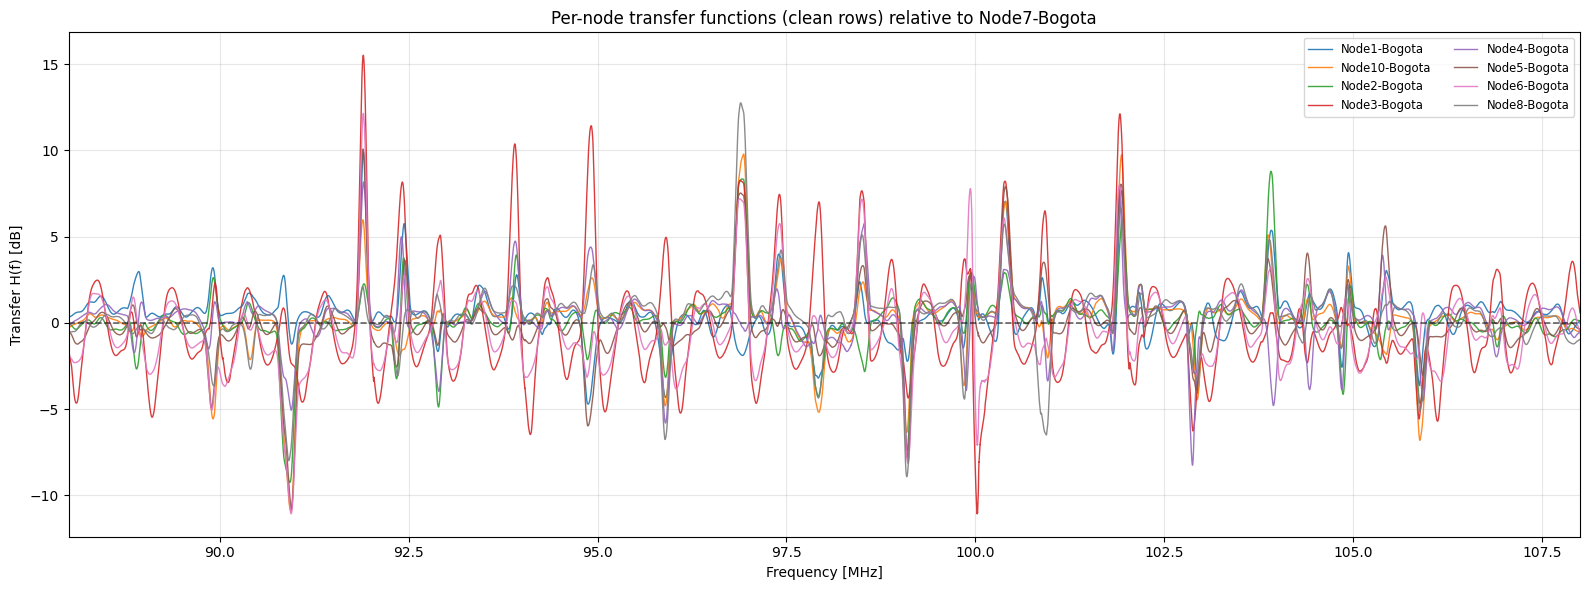

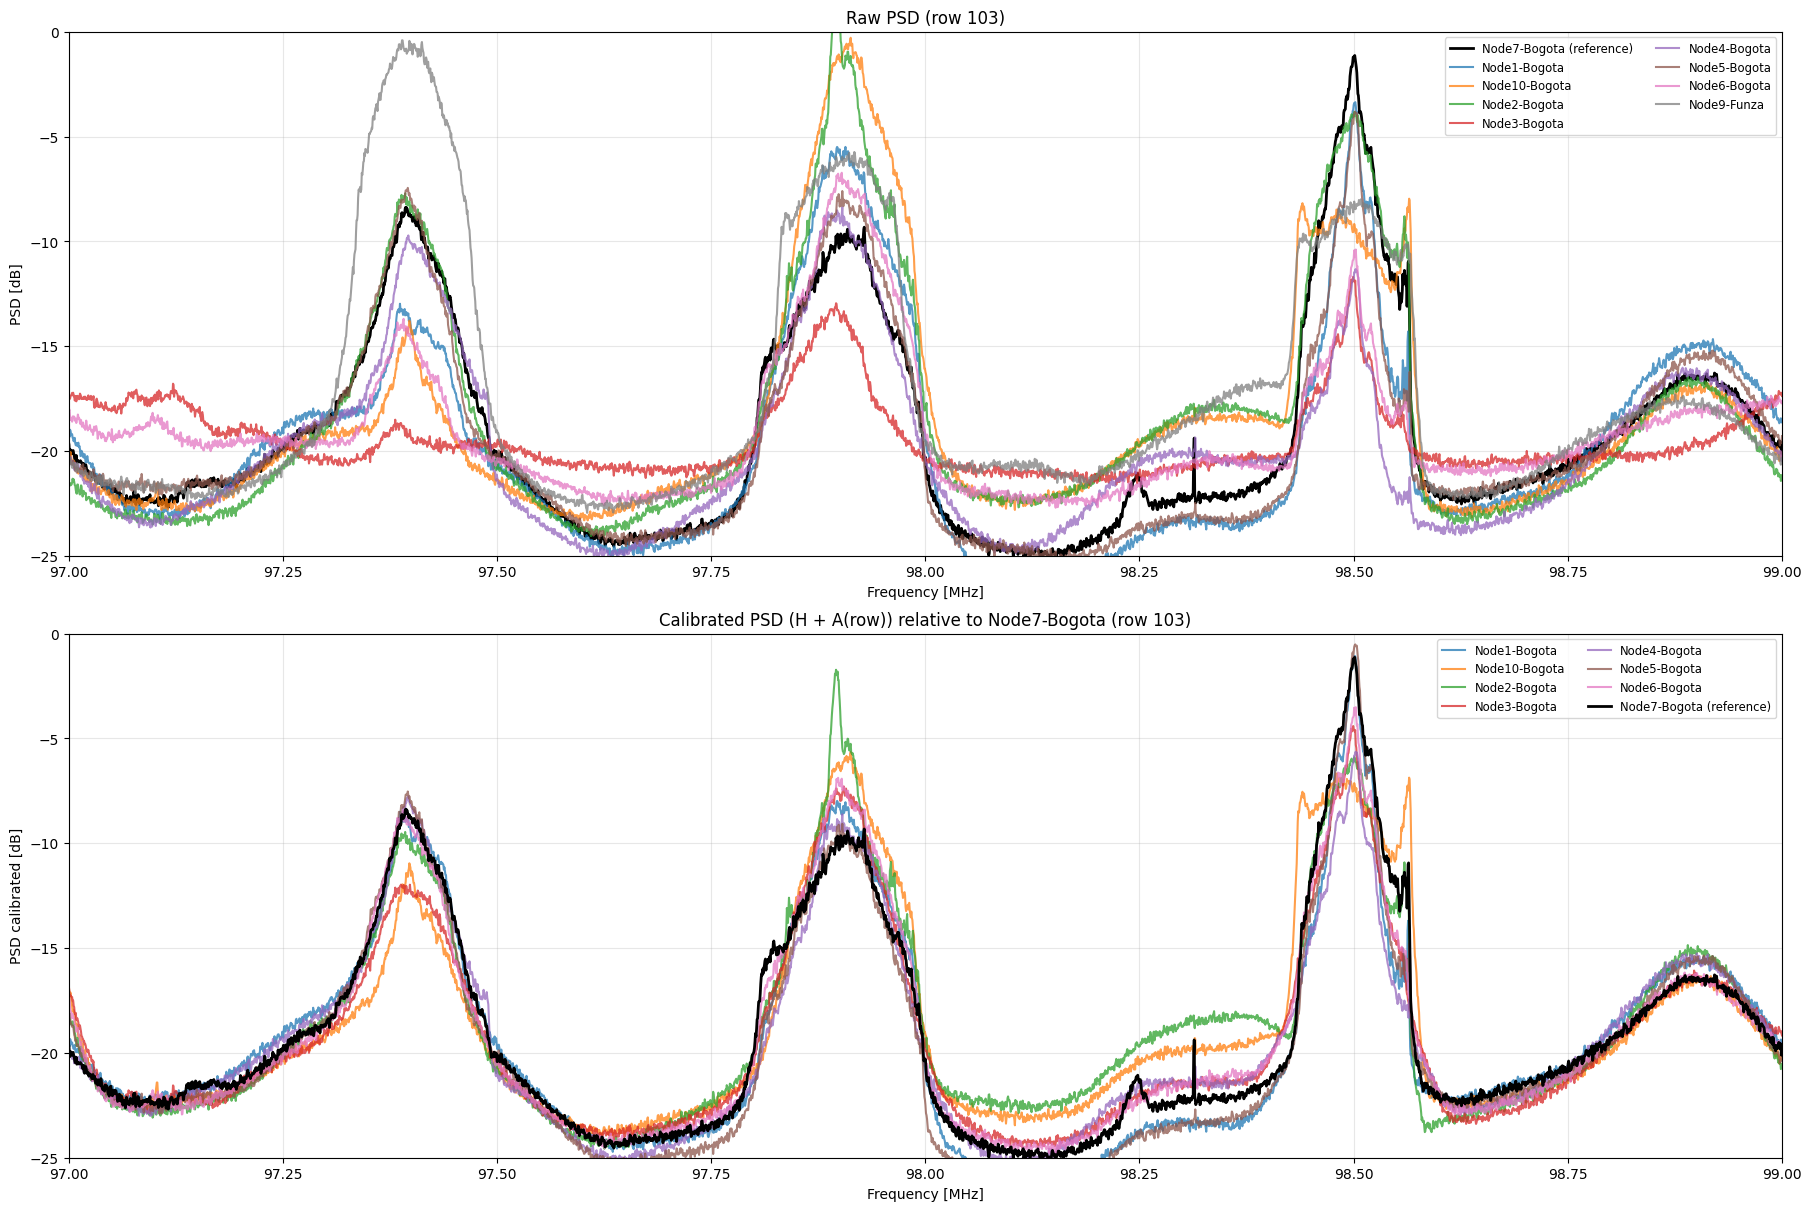

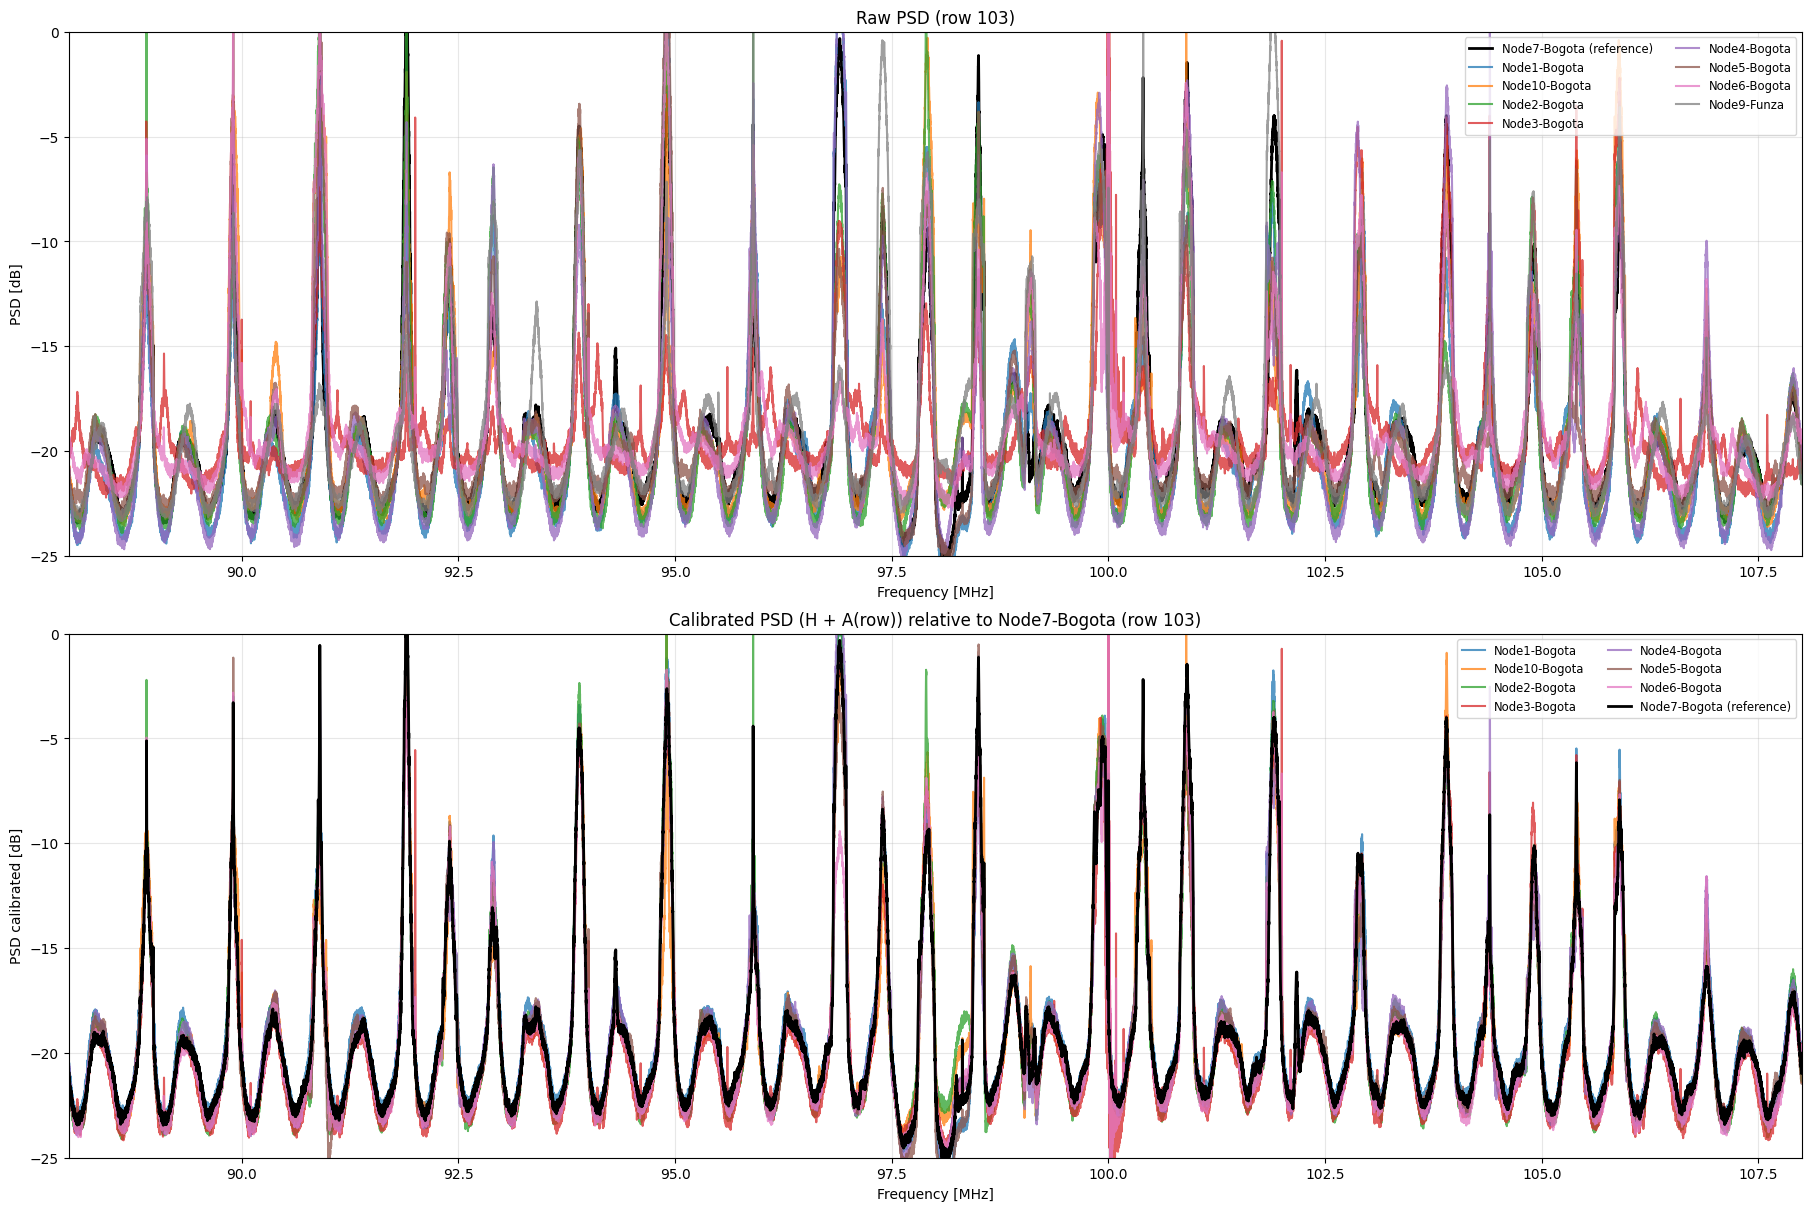

Saved plots:
- data/plots_non_linearity/transfer_functions_clean_rows.png
- data/plots_non_linearity/psd_comparison_row103_roi_97_99_clean_rows.png
- data/plots_non_linearity/psd_comparison_row103_fullband_clean_rows.png


In [4]:
import matplotlib.pyplot as plt


# -----------------------
# Plot configuration
# -----------------------
ROW_PLOT = 103
PLOTS_DIR = Path("data/plots_non_linearity")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


def get_row_psd_on_reference_axis(
    node_df: pd.DataFrame,      # Dataframe of one node
    row_idx: int,               # Snapshot row index to extract
    ref_freq_mhz: np.ndarray,   # Reference frequency axis [MHz]
    pxx_col: str = PXX_COLUMN,  # PSD column name
) -> np.ndarray:                # Node PSD on reference axis [dB]
    '''Extract one node PSD row and interpolate it onto the reference axis.

    Purpose:
    Standardize row extraction for plotting raw and calibrated PSDs with the
    same interpolation used by transfer estimation.

    Parameters:
    node_df: Node dataframe.
    row_idx: Row index to read.
    ref_freq_mhz: Reference frequency axis in MHz.
    pxx_col: Name of PSD column.

    Returns:
    Interpolated PSD vector on `ref_freq_mhz` in dB.

    Side effects:
    None.
    '''
    if not (0 <= int(row_idx) < len(node_df)):
        raise IndexError(f"row_idx={row_idx} is out of range for node with {len(node_df)} rows")

    node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[int(row_idx)])
    node_freq_mhz = frequency_axis_mhz(
        start_freq_hz=float(node_df["start_freq_hz"].iloc[int(row_idx)]),
        end_freq_hz=float(node_df["end_freq_hz"].iloc[int(row_idx)]),
        n_bins=node_psd_db.size,
    )
    return interpolate_psd_to_reference_axis(node_freq_mhz, node_psd_db, ref_freq_mhz)


def plot_transfer_functions(
    freq_ref_mhz: np.ndarray,                     # Reference frequency axis [MHz]
    transfer_db_by_node: Dict[str, np.ndarray],  # Transfer functions H_node(f) [dB]
    reference_node: str = REFERENCE_NODE,        # Name of the reference node
) -> plt.Figure:                                 # Matplotlib figure handle
    '''Plot estimated transfer functions for all fitted non-reference nodes.

    Purpose:
    Visualize node-specific gain correction curves after clean-row filtering.

    Parameters:
    freq_ref_mhz: Reference frequency grid in MHz.
    transfer_db_by_node: Mapping from node name to transfer in dB.
    reference_node: Node used as target response.

    Returns:
    Matplotlib figure object.

    Side effects:
    Renders a matplotlib figure when displayed.
    '''
    fig, ax = plt.subplots(figsize=(16, 6))

    # Plot only fitted non-reference nodes to focus on actual corrections.
    for node_name in sorted(transfer_db_by_node.keys()):
        if node_name == reference_node:
            continue
        ax.plot(freq_ref_mhz, transfer_db_by_node[node_name], linewidth=1.0, alpha=0.9, label=node_name)

    ax.axhline(0.0, linestyle="--", linewidth=1.2, color="black", alpha=0.6)
    ax.set_xlim(freq_ref_mhz.min(), freq_ref_mhz.max())
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Transfer H(f) [dB]")
    ax.set_title(f"Per-node transfer functions (clean rows) relative to {reference_node}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize="small", ncol=2)
    fig.tight_layout()
    return fig


def plot_psd_comparison_for_row(
    data_by_node: Dict[str, pd.DataFrame],         # Raw data by node
    freq_ref_mhz: np.ndarray,                      # Reference frequency axis [MHz]
    transfer_db_by_node: Dict[str, np.ndarray],    # Estimated transfer functions H(f) [dB]
    row_offset_by_node: Dict[str, np.ndarray] | None = None,  # Optional per-row offsets A_i(r) [dB]
    row_plot: int = ROW_PLOT,                      # Row index used for comparison
    reference_node: str = REFERENCE_NODE,          # Node used as target response
    roi_mhz: Tuple[float, float] = ROI_MHZ,        # Frequency window for display [MHz]
) -> plt.Figure:                                   # Matplotlib figure handle
    '''Plot raw vs calibrated PSD comparison for one synchronized row.

    Purpose:
    Compare each node before and after calibration using the clean-row transfer
    estimates while preserving the original spectral interpolation method.

    Parameters:
    data_by_node: Mapping `{node: dataframe}`.
    freq_ref_mhz: Reference axis in MHz.
    transfer_db_by_node: Estimated transfer functions in dB.
    row_offset_by_node: Optional per-row scalar offsets A_i(r) in dB.
    row_plot: Row index to visualize.
    reference_node: Target node for calibration.
    roi_mhz: Display frequency interval in MHz.

    Returns:
    Matplotlib figure object.

    Side effects:
    Renders a matplotlib figure when displayed.
    '''
    if reference_node not in data_by_node:
        raise KeyError(f"Reference node '{reference_node}' not found")

    ref_raw_db = get_row_psd_on_reference_axis(data_by_node[reference_node], row_plot, freq_ref_mhz, pxx_col=PXX_COLUMN)

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(18, 12), sharex=False, constrained_layout=True)

    # Top panel: raw PSD for each node projected to reference frequency axis.
    ax_top.plot(freq_ref_mhz, ref_raw_db, label=f"{reference_node} (reference)", linewidth=2.0, color="black")

    for node_name, node_df in sorted(data_by_node.items()):
        if node_name == reference_node:
            continue
        if row_plot >= len(node_df):
            continue

        raw_on_ref_db = get_row_psd_on_reference_axis(node_df, row_plot, freq_ref_mhz, pxx_col=PXX_COLUMN)
        if np.isfinite(raw_on_ref_db).sum() == 0:
            continue

        ax_top.plot(freq_ref_mhz, raw_on_ref_db, label=node_name, alpha=0.75)

        # Bottom panel: calibrated PSD using H_node(f) + optional A_node(r).
        if node_name in transfer_db_by_node:
            row_offset_db = 0.0
            if row_offset_by_node is not None and node_name in row_offset_by_node:
                node_offsets = np.asarray(row_offset_by_node[node_name], dtype=float).ravel()
                if 0 <= int(row_plot) < node_offsets.size and np.isfinite(node_offsets[int(row_plot)]):
                    row_offset_db = float(node_offsets[int(row_plot)])

            calibrated_db = raw_on_ref_db + transfer_db_by_node[node_name] + row_offset_db
            ax_bot.plot(freq_ref_mhz, calibrated_db, label=node_name, alpha=0.75)

    ax_bot.plot(freq_ref_mhz, ref_raw_db, label=f"{reference_node} (reference)", linewidth=2.0, color="black")

    ax_top.set_title(f"Raw PSD (row {row_plot})")
    ax_top.set_xlabel("Frequency [MHz]")
    ax_top.set_ylabel("PSD [dB]")
    ax_top.grid(True, alpha=0.3)
    ax_top.set_xlim(*roi_mhz)
    ax_top.set_ylim(-25.0, 0.0)
    ax_top.legend(loc="best", fontsize="small", ncol=2)

    ax_bot.set_title(f"Calibrated PSD (H + A(row)) relative to {reference_node} (row {row_plot})")
    ax_bot.set_xlabel("Frequency [MHz]")
    ax_bot.set_ylabel("PSD calibrated [dB]")
    ax_bot.grid(True, alpha=0.3)
    ax_bot.set_xlim(*roi_mhz)
    ax_bot.set_ylim(-25.0, 0.0)
    ax_bot.legend(loc="best", fontsize="small", ncol=2)

    return fig


# -----------------------
# Generate and save plots
# -----------------------
fig_transfer = plot_transfer_functions(
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    reference_node=REFERENCE_NODE,
)
transfer_plot_path = PLOTS_DIR / "transfer_functions_clean_rows.png"
fig_transfer.savefig(transfer_plot_path, dpi=160, bbox_inches="tight")
plt.show()

fig_roi = plot_psd_comparison_for_row(
    data_by_node=data_by_node,
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    row_offset_by_node=row_offset_by_node,
    row_plot=ROW_PLOT,
    reference_node=REFERENCE_NODE,
    roi_mhz=ROI_MHZ,
)
roi_plot_path = PLOTS_DIR / "psd_comparison_row103_roi_97_99_clean_rows.png"
fig_roi.savefig(roi_plot_path, dpi=160, bbox_inches="tight")
plt.show()

fig_full = plot_psd_comparison_for_row(
    data_by_node=data_by_node,
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    row_offset_by_node=row_offset_by_node,
    row_plot=ROW_PLOT,
    reference_node=REFERENCE_NODE,
    roi_mhz=(88.0, 108.0),
)
full_plot_path = PLOTS_DIR / "psd_comparison_row103_fullband_clean_rows.png"
fig_full.savefig(full_plot_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved plots:")
print(f"- {transfer_plot_path}")
print(f"- {roi_plot_path}")
print(f"- {full_plot_path}")
